# The Mathematics of Anthropology — Python 3 teaching notebook

Alexy Khrabrov · Notebook edition 1.0.0 · Companion text 1.0.1

This notebook includes **the complete companion text**, its figures as embedded
attachments, and executable lessons after the corresponding explanations. Read
from top to bottom. Use **Restart Kernel and Run All** for a clean run; then edit
the small input arrays and rerun a lesson to explore what changes. Later cells
depend on earlier ones. Outputs saved here show a verified run, but rerunning is
the way to check your own edits.

Examples use synthetic or explicitly frozen numerical inputs. Dated catalog
counts, archive-wide measurements, model labels, and live-site journeys in the
original text are historical evidence, not claims that this notebook recreates
or refreshes the production archive. No credentials, remote API calls, paid news
access, or live network connection are needed to execute the lessons.

The companion's original diagrams remain embedded reference figures. Lesson
outputs recompute the arithmetic from editable inputs. Exercise suggestions
accompany the examples; assertions check mathematical identities and reference
results. When deliberately changing a fixture, examine and update its expected
results as part of the exercise.

The setup cell defines reusable numerical helpers. Their operations are
introduced in the relevant chapters; you may run it now and return to its code
later. The OCaml edition computes in OCaml and does not call Python. The Python
edition uses NumPy and, where needed, SciPy/Matplotlib.

For environment installation and verification commands, see the included
`README.txt`. Python needs the `math-companion-python` kernel from the teaching environment;
OCaml needs the `ocaml-jupyter` kernel (an installed differently named OCaml
kernel can be selected in Jupyter). Both notebooks retain the same full text.

Original reader: [The Mathematics of Anthropology](https://firstpair.org/read/anthropology-math/).
Manuscript revision: `429e1f79`. Notebook source revision:
`ac612429`. The manuscript and lesson SHA-256 hashes are in notebook metadata.


In [1]:
import json
import math
import numpy as np
np.set_printoptions(precision=6, suppress=True)
results = {}
def record_result(key, value):
    results[key] = float(value)
    print(f"{key} = {value:.12g}")
def unit(row):
    length = np.linalg.norm(row)
    if length == 0:
        raise ValueError("A zero row has no direction")
    return np.asarray(row) / length
def cosine(a, b):
    return float(unit(a) @ unit(b))
def row_times(row, matrix):
    return np.asarray(row) @ matrix
def oriented_eigh(matrix):
    values, directions = np.linalg.eigh(matrix)
    order = np.argsort(values)[::-1]
    values, directions = values[order], directions[:, order]
    for j in range(directions.shape[1]):
        if directions[np.argmax(np.abs(directions[:, j])), j] < 0:
            directions[:, j] *= -1
    return values, directions
def assert_close(actual, expected, tol=1e-9):
    np.testing.assert_allclose(actual, expected, atol=tol, rtol=tol)
def sigmoid(values):
    return 1 / (1 + np.exp(-np.asarray(values)))
print("Ready: all data below are synthetic unless explicitly marked dated audit.")

Ready: all data below are synthetic unless explicitly marked dated audit.


<a id="preface"></a>

# Preface

Anthropology lets a reader start with a person, find the kinds of news associated with that person, follow those news patterns to other people, and return to the articles. Its research paper, [*The Dual Geometry of People and News*](https://firstpair.org/read/anthropology/), describes the system and its evidence. This companion explains the mathematics one operation at a time.

The starting point is [*The Mathematics of Eigen Times*](https://firstpair.org/read/eigentimes-math/). That book explains how articles become vectors, how covariance reveals recurring news directions, and how projections describe a new story. Here we take the next step. A collection of articles associated with a person becomes a profile in news space. A population of profiles produces another set of directions: patterns of how people are covered. One loading matrix connects the two spaces.

You need arithmetic and a willingness to read a small table. The next two chapters introduce the vector and matrix ideas needed to continue. When a prerequisite deserves a longer explanation, a link takes you to the relevant Eigen Times section. We do not repeat its derivations of text weighting, efficient matrix decomposition, or clustering thresholds. We spend that space on the new questions: how to combine a person's articles, what to compare that coverage with, what a people pattern means, why navigation works in both directions, and how shared ontology concepts could connect different news corpora.

One fictional example runs through the book. It has four people, three news coordinates, two source-and-decade cells, and 45 distinct articles. The running example and plotted numerical matrices are generated by the accompanying script. Short additional arithmetic illustrations are written out in the text. Figures use blue for positive values and rust for negative values; color describes a sign, never a judgment about a person. Displayed values are rounded, while computations use their full precision.

The empirical examples come from the Anthropology paper's 2 October 2026 edition. Its people models retain the 1 October snapshot. The catalog has subsequently grown to 59,399 people and organizations, but the fitted models still contain 217 Hacker News profiles and 61 general-news profiles. A catalog identity and a supported mathematical profile are different objects. None of the fictional numbers below is a measurement of a real person.

**Version 1.0.1.** This notation correction introduces symbols, shapes, and operators before their mathematical use. The fictional calculations, empirical measurements, figures, and evidence dates are unchanged.

We will also keep implemented operations separate from research proposals. The published system computes the profiles, people basis, reciprocal indexes, and dated news overlay described here. Incremental profile refresh, learned ontology calibration, and a validated alignment between the two corpora are extensions to evaluate. Explaining their mathematics does not make them deployed features.

## Where to revisit a prerequisite

| If you want more on | Read in the Eigen Times companion |
|---|---|
| Turning words into numbers | [Text as vectors](https://firstpair.org/read/eigentimes-math/chapters/chapter-004.html#text-as-vectors) |
| Dot products and angles | [Cosine similarity](https://firstpair.org/read/eigentimes-math/chapters/chapter-004.html#cosine-similarity) |
| Rows, columns, multiplication, transpose | [Matrices pictured](https://firstpair.org/read/eigentimes-math/chapters/chapter-005.html#matrices-pictured) |
| Means, covariance, and eigenvectors | [The axes of a point cloud](https://firstpair.org/read/eigentimes-math/chapters/chapter-006.html#eigenvectors-the-axes-of-the-cloud) |
| Singular value decomposition (SVD) and low-rank approximation | [The singular value decomposition](https://firstpair.org/read/eigentimes-math/chapters/chapter-007.html#what-the-svd-is) |
| Naming axes by rotation | [Varimax](https://firstpair.org/read/eigentimes-math/chapters/chapter-008.html#varimax) |
| Projection and missing information | [Projection, reconstruction, residual](https://firstpair.org/read/eigentimes-math/chapters/chapter-009.html#projection-reconstruction-residual) |
| Updating sums without rereading everything | [Sums over blocks](https://firstpair.org/read/eigentimes-math/chapters/chapter-013.html#sums-over-blocks) |

<a id="person-as-source"></a>

# What it means to make a person a news source

Imagine collecting articles that mention a database founder. Some concern database systems, some concern enterprise sales, and some concern unrelated activities. Each article can be measured on the same fixed news directions. The collection then has a mathematical shape: it spends more of its coverage in some directions than in others.

That is the sense in which a person becomes a source of news. It is a distribution of associated reporting. It does not mean the person wrote, approved, or caused the articles. Nor is the resulting vector a psychological portrait. Change the corpus (the article collection), the dates, or the attribution rules and the profile can change.

Three objects must remain separate throughout the calculation. An **identity** says which person a record denotes. An **article association** says that a particular article is a candidate match to that person. A **relationship assertion** says something specific, such as that one person reported to another during a stated period, with a source for the claim. A reliable identity does not automatically make every name match reliable. Two people appearing in an article does not establish a relationship between them.

The vector model starts from qualified candidate article associations. Anthropology's graph stores separately sourced assertions and explicitly marked co-mentions. The same interface can display both, but one is not evidence for the other. A short distance in the vector view means similar coverage under that model. A line labeled employment in the graph needs employment evidence.

There will also be two meanings of *people vector*. A **person profile** describes one individual. A **people pattern** is a direction learned from the variation among many profiles. Think of the difference between a city's weather measurements and a recurring weather pattern. A city has coordinates on the pattern; it is not itself the pattern.

The diagram is a roadmap of operations explained below. Project means measure along selected directions; rotate means change their orientation; standardize means divide by reference standard deviations. Center means subtract a comparison mean, and normalize means divide a nonzero row by its length. Principal component analysis (PCA) finds directions of greatest variation among centered observations. These names label the stages, not additional assumptions about a person's identity.

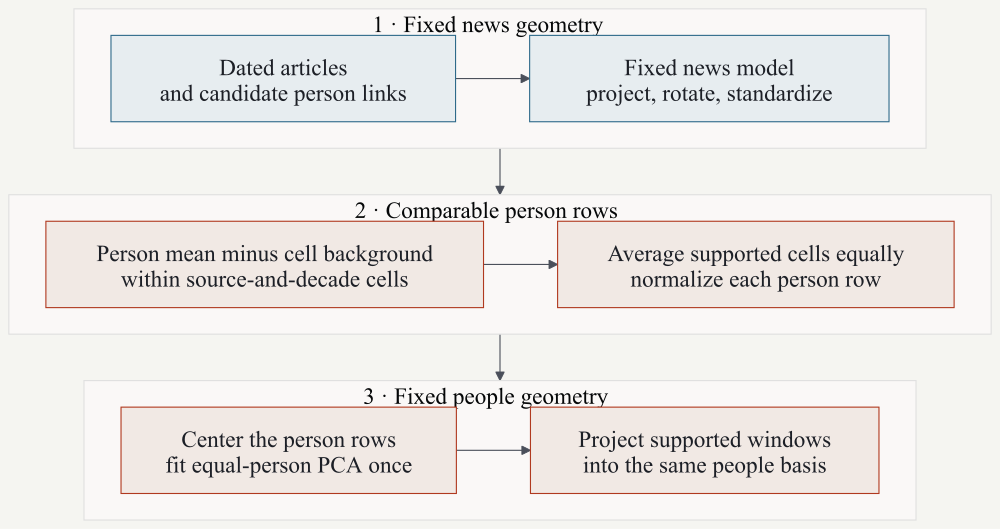

*The mathematical path from articles to person profiles and people patterns. The evidence graph remains a separate route back to sourced claims.*

The book follows this path in the order shown before explaining how the middle can be explored in both directions. At each step we will ask what the numbers mean and what information the operation discards.

**Check 1.** An article names two people. How many unique articles should it contribute to a background average, and how many person-article associations might it contribute? Keep your answer for the solutions at the end.

<a id="small-linear-algebra"></a>

# The small amount of linear algebra we need

## A vector is a measured row

A scalar is a single number. A vector is an ordered list of numbers called coordinates. Our observation vectors are rows; when a matrix direction or another object is a column, we will say so. Let $v$ denote this example row:

$$v=(2,1,-1)$$

It has three coordinates. The order matters: its first coordinate is 2, its second is 1, and its third is -1. In the running example the coordinates belong to three fixed news axes, called N1, N2, and N3. These names identify toy directions, not actual Anthropology topics.

Let $w=(1,0,1)$ be a second row of the same length. The index $j$ selects a coordinate: $v_j$ and $w_j$ are the numbers in position $j$ of the two rows. The summation sign $\sum_j$ means to add over all those positions, from 1 to 3 here. The dot product, written with a centered dot, multiplies corresponding coordinates and adds:

$$v\cdot w=\sum_j v_jw_j.$$

For these rows, the result is $2\times1+1\times0+(-1)\times1=1$. An omitted multiplication sign between scalar entries also means multiply.

The Euclidean length, or norm, of $v$ is written $\lVert v\rVert$. It is the square root of the sum of squared coordinates:

$$\lVert v\rVert=\sqrt{v\cdot v}=\sqrt{2^2+1^2+(-1)^2}=\sqrt6.$$

Dividing a nonzero vector by its length gives a unit vector. It keeps the direction while removing the size. The zero vector has no direction and cannot be normalized this way.

Single bars around a number mean its absolute value, or size without its sign. Thus $|-2|=2$. Single bars around a set will instead count its members; we will introduce those sets before using them. The symbol $\approx$ means approximately equal, as when values have been rounded.

### Laboratory: Compute a dot product and a length

In this cell `v` and `w` are the two three-coordinate rows from the text.
Their dot product adds corresponding products; `unit(v)` divides each
coordinate by the Euclidean length. The assertion checks the printed
arithmetic, and a separate check rejects normalization of a zero row.

In [2]:
v = np.array([2., 1., -1.])
w = np.array([1., 0., 1.])
record_result("vector_dot", v @ w)
record_result("vector_norm", np.linalg.norm(v))
assert_close(v @ w, 1)
assert_close(np.linalg.norm(v), np.sqrt(6))
assert_close(np.linalg.norm(unit(v)), 1)
try:
    unit(np.zeros(3))
    raise AssertionError("A zero row was normalized")
except ValueError:
    print("Zero direction correctly remains undefined.")

vector_dot = 1
vector_norm = 2.44948974278
Zero direction correctly remains undefined.


## A matrix connects two lists of coordinates

A matrix is a rectangular table. Let $n$ count its rows and $K$ its columns; its shape is written $n\times K$. Put one three-coordinate person profile in each of four rows and the result is $4\times3$. A matrix entry uses its row index first and column index second. Diagonal entries have equal row and column indices; they run from the top left toward the bottom right.

Multiplication describes a weighted combination. Its numerical weights are coefficients; coefficients expressing directions in input coordinates are also called loadings. If $h$ is a $1\times3$ row and $W$ is a $3\times2$ loading matrix, then $hW$ is a $1\times2$ row. Its first number is the dot product of $h$ with the first column of $W$. Its second number uses the second column. The adjacent dimensions must agree:

$$ (1\times3)(3\times2)=(1\times2). $$

The transpose, written $W^{\mathsf T}$, exchanges rows and columns. It therefore has shape $2\times3$. Remembering shapes will prevent more mistakes than memorizing a complicated formula.

## Centering gives a comparison point

Suppose three measurements are 2, 3, and 7. Their mean is 4. Centering subtracts that mean, giving -2, -1, and 3. A negative centered value means below the chosen mean; it does not mean a negative amount of the original quantity.

For vector rows we average each column separately and subtract the resulting mean row. We will center twice for different purposes: first against a news background within a source-and-decade cell, then against the mean profile of the fitted population. These are two different comparisons, not a redundant repetition.

Variance measures spread by averaging squared deviations from a mean. A standard deviation is the nonnegative square root of a variance; it is zero when all values agree. Covariance averages the product of the centered values of two coordinates: a positive result means they tend to move together, a negative result means they tend to move oppositely. A covariance matrix collects those comparisons for every pair of coordinates. Its diagonal contains their individual variances. The fitted news model supplies its covariance convention; for the people calculation below we explicitly divide by the number of people.

### Laboratory: Center observations and check dimensions

`measurements` contains the scalar observations 2, 3, and 7, and
`centered_measurements` subtracts their average. The second calculation
uses a **synthetic shape-only** 60-by-24 loading table called `shape_map`;
its first 24 columns select coordinates. It demonstrates the book's
dimensions without inventing production loadings. The OCaml cell temporarily
abbreviates displayed arrays and returns their shapes in `shape_summary`;
this changes display only, and every matrix is still computed in full.

In [3]:
measurements = np.array([2., 3., 7.])
centered_measurements = measurements - measurements.mean()
assert_close(centered_measurements, [-2, -1, 3])
record_result("scalar_mean", measurements.mean())
shape_map = np.eye(60)[:, :24]
shape_row = np.arange(60.)[None, :]
assert (shape_row @ shape_map).shape == (1, 24)
assert (shape_map @ shape_map.T).shape == (60, 60)
record_result("shape_projection_rank", np.linalg.matrix_rank(shape_map @ shape_map.T))
print("Centered:", centered_measurements, "; row × loadings:", (shape_row @ shape_map).shape)

scalar_mean = 4
shape_projection_rank = 24
Centered: [-2. -1.  3.] ; row × loadings: (1, 24)


## Rotation and projection are different operations

Perpendicular directions have dot product zero. Perpendicular unit directions are *orthonormal*. Let $I$ denote an identity matrix: it has ones on its diagonal and zeros elsewhere, so multiplying by it changes nothing. Its size matches the matrix product beside it. Let $R$ be a square matrix whose columns form a complete orthonormal system. Such a matrix is called orthogonal and satisfies $R^{\mathsf T}R=RR^{\mathsf T}=I$. Multiplying by $R$ rotates or reflects coordinates and preserves all lengths and angles.

A tall matrix $W$ can also have orthonormal columns: $W^{\mathsf T}W=I$. But when it has fewer columns than rows, multiplying by $W$ keeps only some directions. The length can decrease. The statement that an orthogonal change of coordinates preserves lengths applies to a complete rotation; a truncated projection preserves only the retained component. This distinction will explain the navigation duality.

Directions are linearly independent when none is a weighted combination of the others. A basis is a set of independent directions used to express coordinates. The subspace spanned by a collection of directions contains all their weighted combinations. The rank of a matrix counts its independent directions; keeping fewer directions is a low-rank representation.

The [Eigen Times matrix pictures](https://firstpair.org/read/eigentimes-math/chapters/chapter-005.html#matrices-pictured) provide a longer visual introduction. When comparing a formula written with column vectors to this book, transpose it consistently rather than changing only one factor.

**Check 2.** A row has 60 news coordinates and its loading matrix $W$ has shape $60\times24$. What are the shapes of the forward result, the transpose, the combined matrix $WW^{\mathsf T}$, and the returned row?

<a id="article-coordinates"></a>

# Measuring an article on named news axes

## First inherit a fixed news map

Eigen Times and Eigen Hacks turn an article's text into an embedding, a list of numbers produced by a text model. Anthropology does not learn a new text embedding for every person. It inherits a versioned news coordinate system and measures each associated article in that system.

Let $a$ index an article and $d$ count embedding coordinates. Let $x_a$ be article $a$'s $1\times d$ embedding row, and $\mu$ the $1\times d$ mean embedding used when the news basis was fitted. Let $K$ count retained news directions and let $V$ contain them as orthonormal columns, so $V$ has shape $d\times K$. Denote the resulting $1\times K$ raw news-coordinate row by $c_a$:

$$c_a=(x_a-\mu)V.$$

Read this in two steps: subtract the reference mean, then take a dot product with each retained direction. In the audited implementation, $d=384$ and $K=60$. This projection has already discarded information before people enter the calculation.

Why these particular directions? They are the directions of greatest fitted variation, found from a covariance matrix. The [Eigen Times covariance chapter](https://firstpair.org/read/eigentimes-math/chapters/chapter-006.html#centering-and-covariance) develops that argument. For the moment, regard $V$ as a fixed measuring instrument, accompanied by its mean and version.

## Naming changes orientation

A statistically useful direction need not have a readable name. Eigen applies a stored $K\times K$ orthogonal rotation $R$. Denote the resulting $1\times K$ named news-coordinate row by $y_a$:

$$y_a=c_aR.$$

Lexical loadings measure associations between words and numerical directions. Varimax is an orientation rule that makes these loadings more concentrated on individual axes. Eigen uses it to choose the rotation, helping some axes acquire recognizable word lists. The [Eigen Times varimax explanation](https://firstpair.org/read/eigentimes-math/chapters/chapter-008.html#varimax) shows why this can improve interpretability.

An ontology is a reusable vocabulary of concepts and their relationships. The word lists are labels to investigate, not ontology definitions. Stemming shortens words by removing endings, so a label such as `databas` represents a processed word form. A list containing `databas`, `ceo`, and `interview` can describe mixed coverage. An axis has two poles: its positive and negative directions. Positive-loading words may describe one pole better than the other. In the implementation, the lexical naming fit uses raw scores divided by their standard deviations, called standardized raw scores, while the stored rotation acts on unstandardized article scores. Operations commute when changing their order leaves the result unchanged. Scaling and rotation need not commute, so the lexical lists are a naming heuristic rather than exact term contributions to every final coordinate.

## Put each named coordinate in comparable units

Some named directions vary more than others. A coordinate of 2 on one direction may be ordinary while 2 on another is unusual. Anthropology divides each named coordinate by its fitted standard deviation.

Let $j$ index named news axes, from 1 to $K$, and let $\sigma_j$ be the positive standard deviation of axis $j$. Let $D$ be the $K\times K$ diagonal matrix containing those scales: its row-$j$, column-$j$ entry is $D_{jj}=\sigma_j$, and all off-diagonal entries are zero. The superscript $-1$ denotes a matrix inverse, which undoes the corresponding multiplication. Here $D^{-1}$ has reciprocal scales on its diagonal, so multiplying by it divides coordinate $j$ by $\sigma_j$. Denote the standardized $1\times K$ article row by $z_a$:

$$z_a=y_aD^{-1}.$$

For example, with standard deviations $(2,1,0.5)$, named coordinates $(4,1,-1)$ become standardized coordinates $(2,1,-2)$. When discussing a generic article we omit its subscript and write $z$ for such a standardized row; $z_j$ is its coordinate $j$. We will aggregate these rows into people profiles.

An eigenvector of a covariance matrix is a direction that multiplication by that matrix stretches without turning; its eigenvalue is the stretch factor. Let $i$ index the retained raw axes, from 1 to $K$, and let $\lambda_i$ be their positive fitted variances, which are eigenvalues of the raw covariance. The coefficient $R_{ij}$ is the entry in row $i$, column $j$ of the rotation. Summing over all raw axes gives each named-axis variance:

$$\sigma_j^2=\sum_i\lambda_iR_{ij}^{2}.$$

Each rotated variance is a weighted combination of raw variances. The squared rotation coefficients supply the weights. The mean, directions, rotation, variances, and corpus identity must travel together. Axis N24 in one model is not automatically N24 in another.

### Laboratory: Reconstruct the complete toy article input

The fictional corpus has eight batches (`batch_names`), each representing
`counts` distinct articles with the same standardized news row in `z`.
Its three axes are N1, N2, N3. E1–E4 belong to the early cell; L1–L4 to the
late cell. These rows and multiplicities are the book's entire 45-article
fixture. The inherited news mean `news_mean`, identity news directions,
identity naming rotation, and coordinate scales `news_scale` are **already
fitted toy parameters**, not estimates from these 45 articles. We construct
embedding rows `x`, then recover standardized rows `z_recovered`.

In [4]:
batch_names = ["E1", "E2", "E3", "E4", "L1", "L2", "L3", "L4"]
z = np.array([[2,0,1],[1,1,2],[0,2,2],[-1,0,-2],
              [1,-1,2],[2,1,-2],[0,3,2],[-2,0,-1]], dtype=float)
counts = np.array([10,5,5,5,5,5,5,5])
news_mean = np.array([1.,1.,1.])
news_scale = np.array([2.,1.,.5])
news_directions = np.eye(3)
naming_rotation = np.eye(3)
x = news_mean + z * news_scale
z_recovered = ((x - news_mean) @ news_directions @ naming_rotation) / news_scale
assert_close(z_recovered, z)
assert_close(np.array([4.,1.,-1.]) / news_scale, [2,1,-2])
record_result("unique_articles", counts.sum())
print("Batch standardized rows:\n", z_recovered)

unique_articles = 45
Batch standardized rows:
 [[ 2.  0.  1.]
 [ 1.  1.  2.]
 [ 0.  2.  2.]
 [-1.  0. -2.]
 [ 1. -1.  2.]
 [ 2.  1. -2.]
 [ 0.  3.  2.]
 [-2.  0. -1.]]


## Standardization is not whitening

Marginal standardization gives each coordinate unit variance separately. Whitening would also make the covariance between different coordinates zero; we will see that these are different operations. In this illustration only, use two raw directions with variances 4 and 1. Rotate them by 45 degrees using the following $2\times2$ matrix:

$$R=\frac1{\sqrt2}\begin{pmatrix}1&-1\\1&1\end{pmatrix}.$$

Write $\operatorname{Cov}(z)$ for the feature covariance matrix of the standardized article rows in this illustration. Both rotated coordinates have variance 2.5, but they also have covariance -1.5. Divide both by $\sqrt{2.5}$ and their variances become 1 while their covariance becomes -0.6:

$$\operatorname{Cov}(z)=\begin{pmatrix}1&-0.6\\-0.6&1\end{pmatrix}.$$

They now have the same marginal scale. They still move together. Correlation is covariance divided by the two standard deviations; when both variances are one, the correlation equals the covariance. Full whitening would remove these off-diagonal correlations. This pipeline performs marginal standardization, not full whitening.

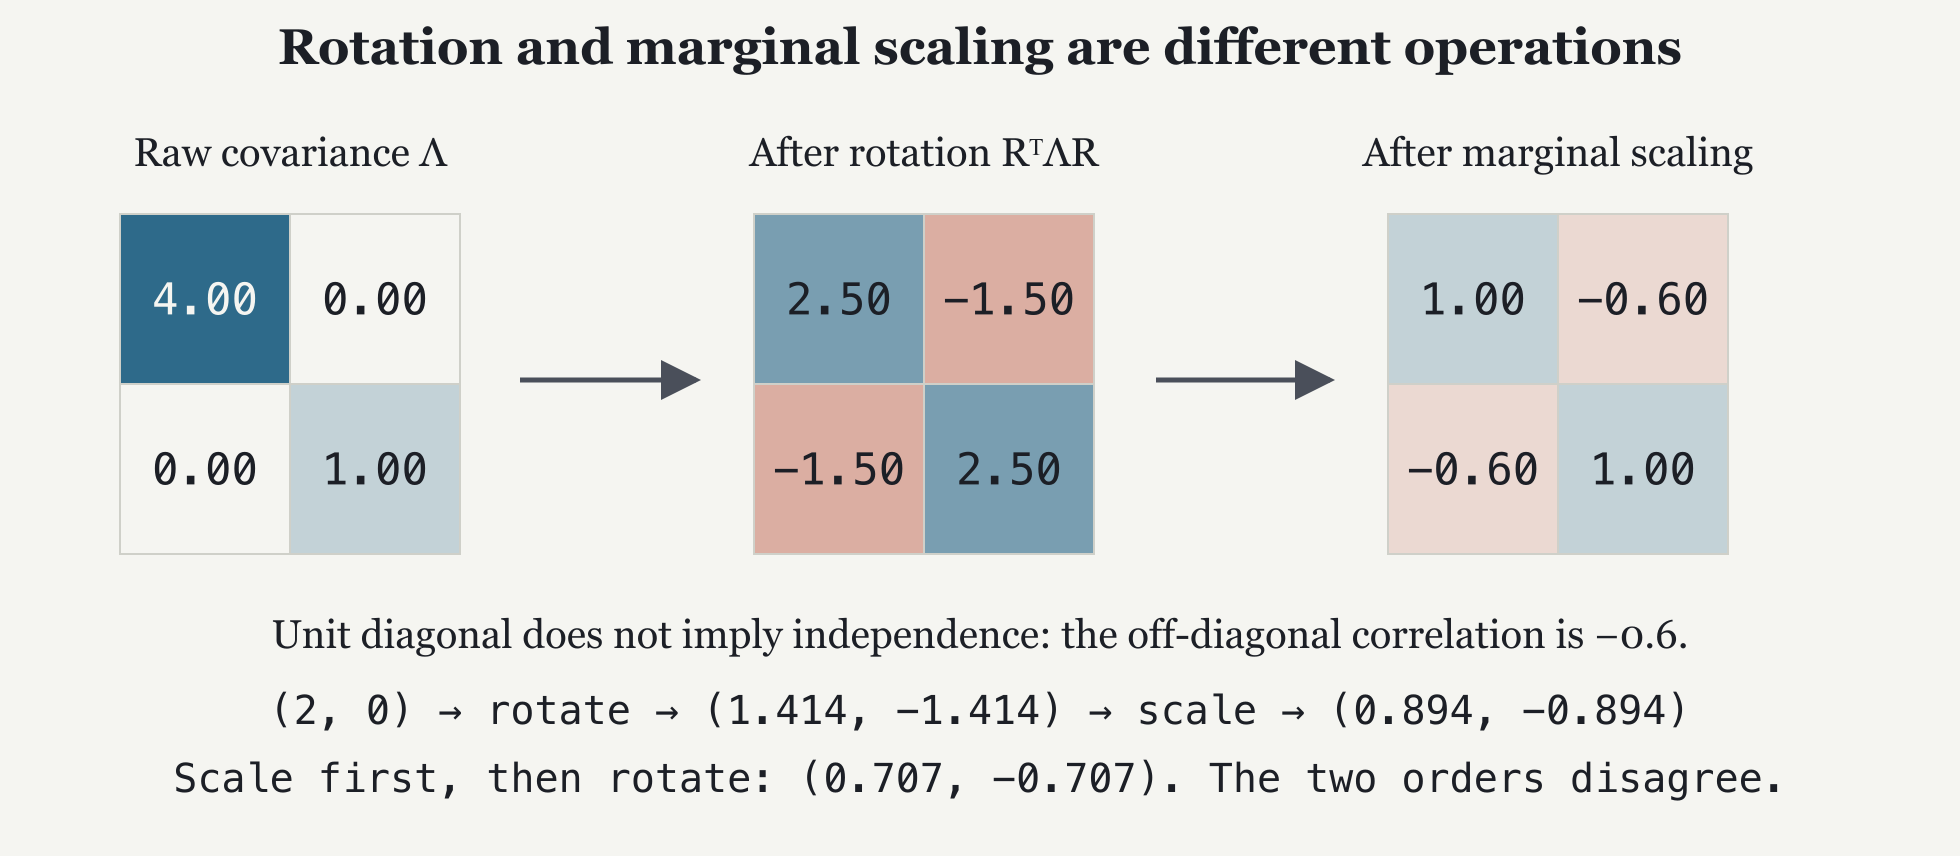

*A rotation mixes the raw variances. Dividing by the new marginal standard deviations gives unit diagonal entries but leaves correlation.*

For the raw row $(2,0)$, rotating and then marginally scaling gives approximately $(0.894,-0.894)$. Scaling the raw coordinates first by $(2,1)$ and then rotating gives $(0.707,-0.707)$. The two operations answer different questions. Their order must be part of the model definition.

This also changes the geometry in which people are compared. Equal lengths in standardized news units need not be equal lengths in the original embedding. A Mahalanobis statistic measures squared distance from a reference mean while accounting for covariance, not just each coordinate's separate scale. The sum $\sum_jz_j^2$ is not generally that original statistic; see [the Eigen Times section on residuals and T squared](https://firstpair.org/read/eigentimes-math/chapters/chapter-009.html#t%C2%B2-and-q). Outside this two-dimensional illustration, the symbols retain their fitted-model meanings.

**Check 3.** Does a covariance matrix with ones on its diagonal necessarily describe uncorrelated coordinates? Use the two-dimensional example to answer.

### Laboratory: Rotate, standardize, and whiten separately

This separate two-coordinate example starts with covariance `raw_cov`
equal to diag(4,1) and a 45-degree orthogonal rotation `rotation`.
`named_cov` is the rotated covariance; `standard_cov` divides each
covariance entry by its two marginal standard deviations. For comparison,
the symmetric inverse square root `whitener` changes the whole covariance
to the identity. Whitening is an **illustrative alternative**, not the
deployed marginal-standardization rule. `raw_row` is (2,0).

In [5]:
angle = np.pi / 4
rotation = np.array([[np.cos(angle),-np.sin(angle)], [np.sin(angle),np.cos(angle)]])
raw_cov = np.diag([4.,1.])
named_cov = rotation.T @ raw_cov @ rotation
named_scale = np.sqrt(np.diag(named_cov))
standard_cov = named_cov / np.outer(named_scale, named_scale)
raw_row = np.array([2.,0.])
named_row = raw_row @ rotation
standard_row = named_row / named_scale
scale_first_row = (raw_row / np.array([2.,1.])) @ rotation
assert_close(standard_cov, [[1,-.6],[-.6,1]])
assert_close(raw_row @ raw_row, named_row @ named_row)
assert not np.allclose(standard_row, scale_first_row)
values2, directions2 = oriented_eigh(named_cov)
whitener = directions2 @ np.diag(1 / np.sqrt(values2)) @ directions2.T
assert_close(whitener.T @ named_cov @ whitener, np.eye(2))
record_result("standardized_off_diagonal", standard_cov[0,1])
record_result("standardized_energy", standard_row @ standard_row)
print("Rotated covariance:\n", named_cov, "\nMarginally standardized:\n", standard_cov)
print("Rotate then scale:", standard_row, "; scale then rotate:", scale_first_row)

standardized_off_diagonal = -0.6
standardized_energy = 1.6
Rotated covariance:
 [[ 2.5 -1.5]
 [-1.5  2.5]] 
Marginally standardized:
 [[ 1.  -0.6]
 [-0.6  1. ]]
Rotate then scale: [ 0.894427 -0.894427] ; scale then rotate: [ 0.707107 -0.707107]


<a id="person-profile"></a>

# Combining articles into a person profile

## Start with associations and keep the background unique

Our fictional example has people A, B, C, and D. The 45 distinct articles are grouped below only to save space: articles in a batch have identical toy coordinates and associations. They are distinct observations, not duplicate records to count repeatedly. E and L identify two source-and-decade cells. A cell specifies both the source and the decade; the letters do not imply that every early or late article belongs together.

The coordinates in the table are already standardized news coordinates $z$. Their reference basis and scales are stipulated for this toy example, not estimated from the 45 rows.

| Batch | Cell | Distinct articles | N1 | N2 | N3 | Associated people |
|---|---|---:|---:|---:|---:|---|
| E1 | E | 10 | 2 | 0 | 1 | A, B |
| E2 | E | 5 | 1 | 1 | 2 | A |
| E3 | E | 5 | 0 | 2 | 2 | C |
| E4 | E | 5 | -1 | 0 | -2 | D |
| L1 | L | 5 | 1 | -1 | 2 | A |
| L2 | L | 5 | 2 | 1 | -2 | B |
| L3 | L | 5 | 0 | 3 | 2 | B, C |
| L4 | L | 5 | -2 | 0 | -1 | D |

There are 25 distinct articles in E and 20 in L. A has 20 associated articles, B has 20, and C and D have 10 each. Thus there are 60 person-article associations but only 45 unique articles. The ten E1 articles each name two people, as do the five L3 articles. This is why adding person counts is not a way to count the archive.

An *incidence matrix* records these associations. Its rows are people, its columns are articles, and an entry is 1 when the article is associated with the person and 0 otherwise. It is a bookkeeping device; it does not turn the association into a verified identity match or a social relationship. The figure compresses identical article columns into one column per batch, with its multiplicity shown below.

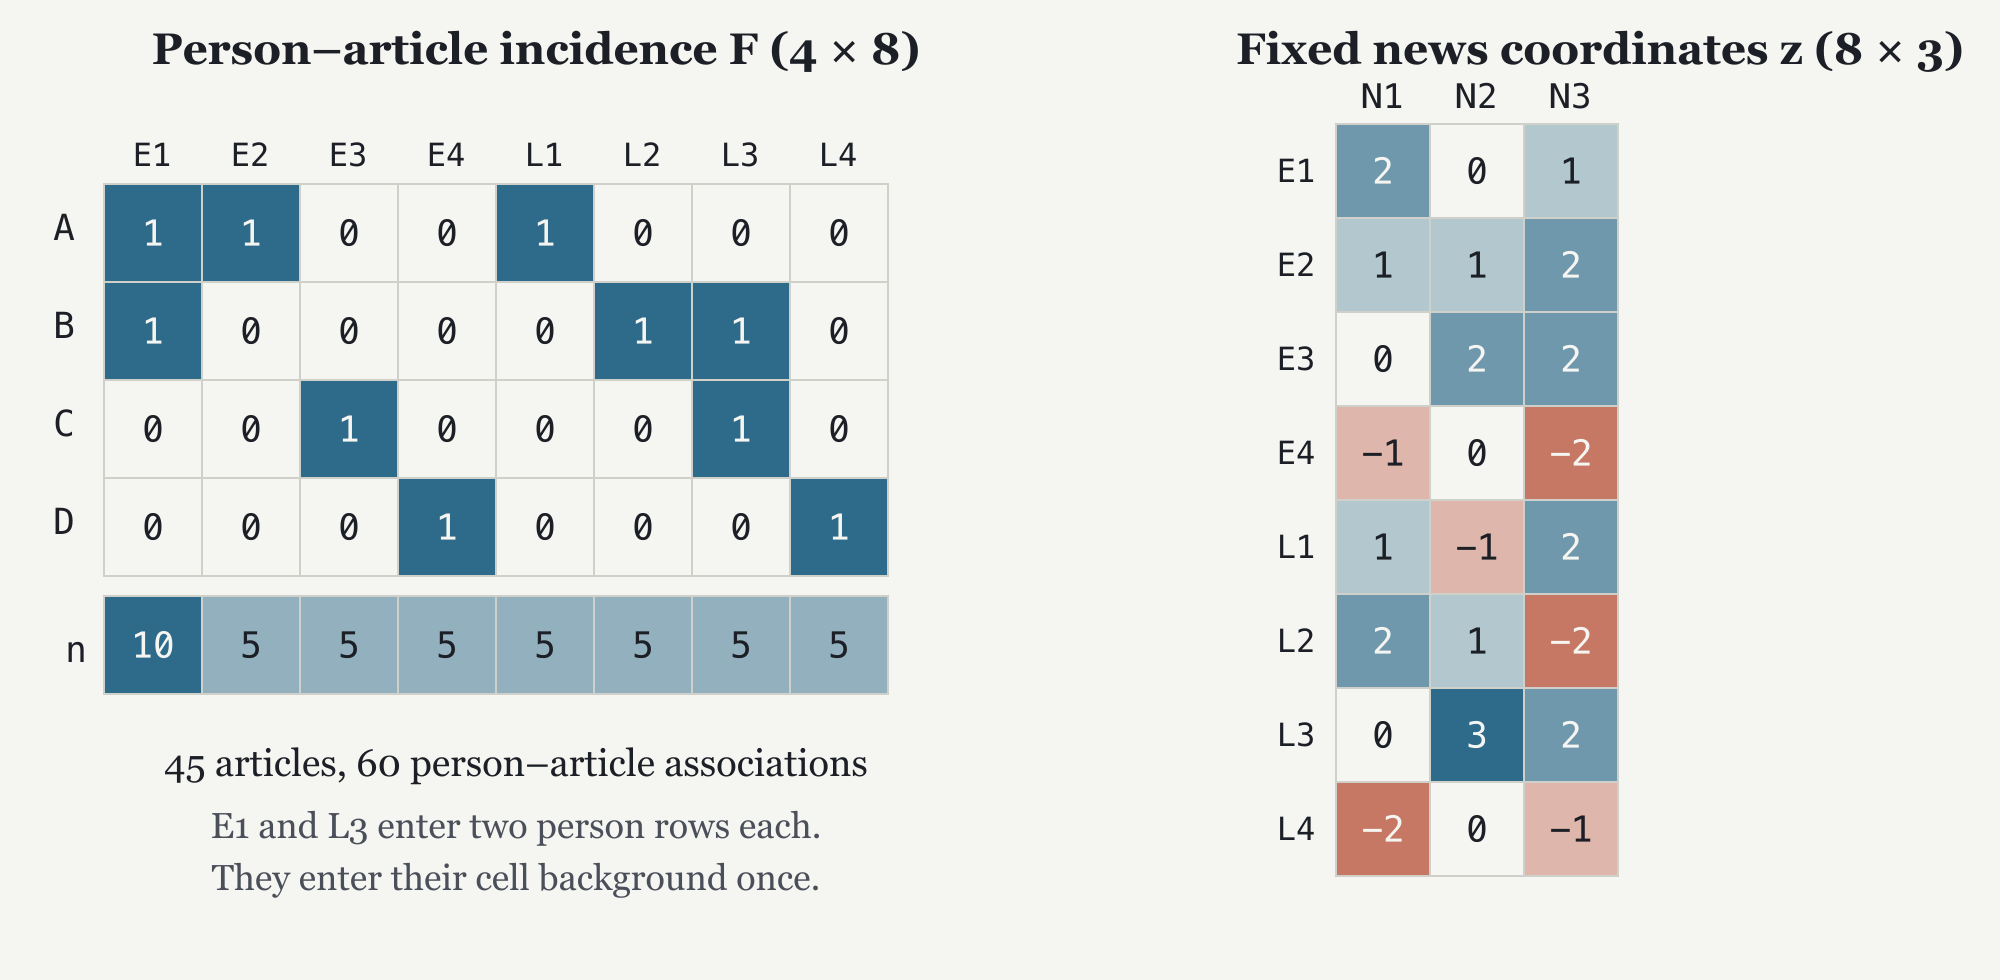

*The toy association table and fixed news coordinates. Shared batches contribute to more than one person but only once to a cell's background.*

### Laboratory: Expand batches and deduplicate by article identity

Rows of the binary `incidence` table are fictional people A–D; columns
are the eight batches. A one means every article in that batch is
associated with that person. `article_records` gives each individual
article a distinct identifier. `association_pairs` stores person/article
pairs; inserting a duplicate pair must not create another observation.
The background counts unique articles, not person/article pairs.

In [6]:
people = ["A","B","C","D"]
incidence = np.array([[1,1,0,0,1,0,0,0], [1,0,0,0,0,1,1,0],
                      [0,0,1,0,0,0,1,0], [0,0,0,1,0,0,0,1]])
article_records = [(f"{name}-{i+1}", j) for j,name in enumerate(batch_names) for i in range(counts[j])]
association_pairs = {(people[p], article_id) for article_id,j in article_records
                     for p in range(4) if incidence[p,j]}
duplicate_input = list(association_pairs) + [next(iter(association_pairs))]
assert len(set(duplicate_input)) == len(association_pairs) == 60
assert len({a for a,j in article_records}) == 45
person_totals = incidence @ counts
assert_close(person_totals, [20,20,10,10])
record_result("person_article_associations", len(association_pairs))
print("Unique articles / associations:", len(article_records), len(association_pairs))
print("A–D article counts:", person_totals)

person_article_associations = 60
Unique articles / associations: 45 60
A–D article counts: [20 20 10 10]


## A cell supplies its own comparison

Let $p$ index a person and $g$ a source-and-decade cell. Let $\mathcal A_g$ be the set of unique eligible background articles in cell $g$, and $\mathcal A_{pg}$ its subset associated with person $p$. For any set $\mathcal A$, $|\mathcal A|$ denotes its number of members, called its cardinality. The notation $a\in\mathcal A_g$ means that article $a$ belongs to that set; a sum with that condition includes each member once. Recall that $z_a$ is article $a$'s standardized news-coordinate row. Let $q_g$ be the background mean and $m_{pg}$ the person-cell mean, both $1\times K$ rows. For nonempty article sets, divide the coordinate sums by their respective article counts:

$$q_g=\frac{\sum_{a\in\mathcal A_g}z_a}{|\mathcal A_g|},\qquad
m_{pg}=\frac{\sum_{a\in\mathcal A_{pg}}z_a}{|\mathcal A_{pg}|}.$$

The background is drawn from qualified candidate-associated articles, not from every article in the news corpus.

Write $q_{E,1}$ for the first coordinate of cell E's background row. It is

$$q_{E,1}=\frac{10(2)+5(1)+5(0)+5(-1)}{25}=0.8.$$

Computing the other coordinates in the same way gives

$$q_E=(0.8,0.6,0.8),\qquad q_L=(0.25,0.75,0.25).$$

Now consider A. Its 15 E articles have mean $(1.6667,0.3333,1.3333)$; its five L articles have mean $(1,-1,2)$. Subtracting each cell's background gives

$$m_{AE}-q_E=(0.8667,-0.2667,0.5333),$$
$$m_{AL}-q_L=(0.75,-1.75,1.75).$$

The question has changed from “what is A's coverage like?” to “how does A's coverage differ from its available comparison coverage in each cell?” A negative coordinate means relatively less in that direction, not an absence of articles or disagreement with a topic.

### Laboratory: Compute person means and unique-article backgrounds

`cell_indices` identifies the early and late four-batch cells.
`backgrounds[g]` averages unique articles in cell `g`; `cell_means[p,g]`
averages articles associated with person `p` there. `cell_counts[p,g]`
counts that person's supporting articles. `contrasts` subtracts the
matching background from each personal mean. Multiplicities represent
distinct articles, not duplicate copies of one identifier.

In [7]:
cell_indices = [np.arange(4), np.arange(4,8)]
backgrounds = np.array([np.average(z[idx], axis=0, weights=counts[idx]) for idx in cell_indices])
cell_counts = np.zeros((4,2), dtype=int)
cell_means = np.zeros((4,2,3))
for p in range(4):
    for g,idx in enumerate(cell_indices):
        weights = incidence[p,idx] * counts[idx]
        cell_counts[p,g] = weights.sum()
        cell_means[p,g] = np.average(z[idx], axis=0, weights=weights)
contrasts = cell_means - backgrounds
assert_close(backgrounds, [[.8,.6,.8],[.25,.75,.25]])
assert_close(cell_means[0], [[5/3,1/3,4/3],[1,-1,2]])
assert_close(contrasts[0], [[13/15,-4/15,8/15],[.75,-1.75,1.75]])
record_result("early_background_N1", backgrounds[0,0])
record_result("late_background_N1", backgrounds[1,0])
print("Cell support (A–D):\n", cell_counts, "\nBackgrounds:\n", backgrounds)
print("A cell means:\n", cell_means[0], "\nA contrasts:\n", contrasts[0])

early_background_N1 = 0.8
late_background_N1 = 0.25
Cell support (A–D):
 [[15  5]
 [10 10]
 [ 5  5]
 [ 5  5]] 
Backgrounds:
 [[0.8  0.6  0.8 ]
 [0.25 0.75 0.25]]
A cell means:
 [[ 1.666667  0.333333  1.333333]
 [ 1.       -1.        2.      ]] 
A contrasts:
 [[ 0.866667 -0.266667  0.533333]
 [ 0.75     -1.75      1.75    ]]


## Give supported cells equal weight

A has three times as many articles in E as in L. If we pooled the articles, E would dominate. Let $\mathcal G_p$ be the set of cells with enough articles for person $p$; $|\mathcal G_p|$ counts retained cells. In production, a cell needs at least five articles associated with that person. For a nonempty retained-cell set, let $r_p$ be the $1\times K$ balanced contrast row. The implemented aggregation computes it by averaging the supported cell contrasts equally:

$$r_p=\frac1{|\mathcal G_p|}\sum_{g\in\mathcal G_p}(m_{pg}-q_g).$$

In the toy example both cells qualify for every person. A's average contrast is therefore

$$r_A=(0.8083,-1.0083,1.1417).$$

For comparison, weighting A's two contrasts in the article-count ratio 15:5 would give $(0.8375,-0.6375,0.8375)$. Neither averaging rule is a law of nature. They encode different questions. Equal supported-cell weighting prevents a densely covered cell from receiving greater weight merely because it contains more articles.

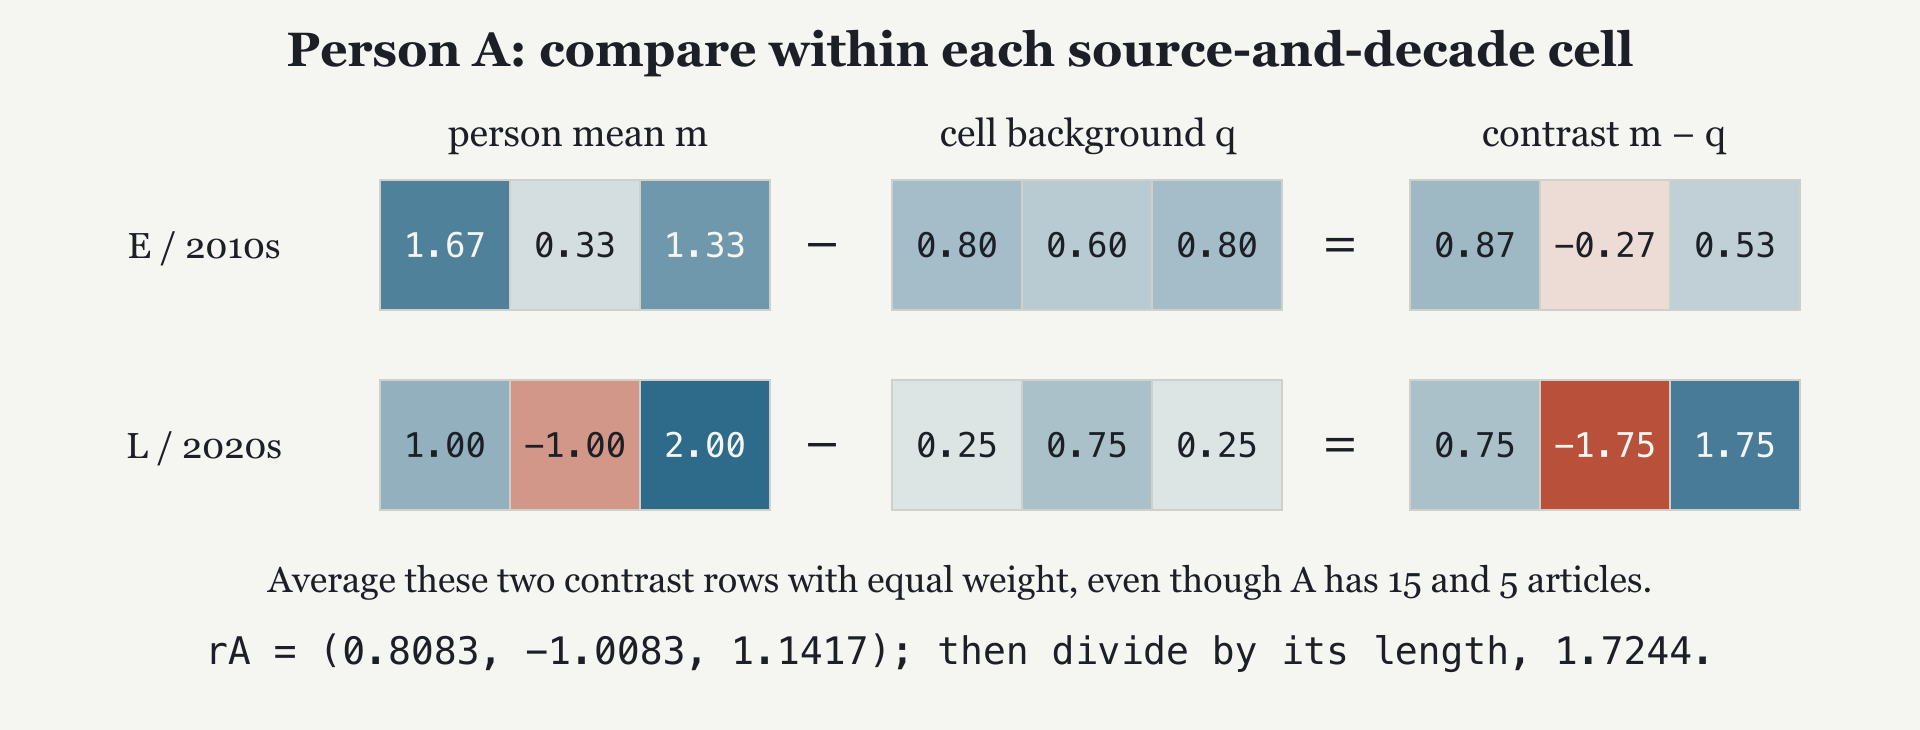

*For A, compute a mean in each cell, subtract the cell background, and average the two contrasts. Equal-cell and article-count weighting estimate different quantities.*

Equal cell weights are not necessarily equal source weights. A source spanning three supported decades contributes three cells, while another source spanning one contributes one. Nor does background subtraction remove every archive bias. It changes a specified comparison, within the selected coverage that is available.

The production gates require at least five articles in a person-cell and at least ten across the retained cells for a person-window. The contrast must also have nonzero numerical length. A cell with four articles is not quietly padded, and an unsupported profile is missing rather than a zero vector. These are operational support rules, not a proof of statistical reliability.

### Laboratory: Apply support gates before averaging

`balanced_profile` first keeps cells with at least five articles, then
requires at least ten articles **across those retained cells**. Its `total`
argument records and checks the all-cell count, which is not the gate's
denominator. It averages retained contrasts with one vote per cell.
An absent result denotes insufficient support; it is not a zero profile.
All four fixture people qualify. `volume_weighted` is a comparison rule
using article counts and is not the equal-cell rule.

In [8]:
def balanced_profile(support, cell_contrasts, total):
    eligible = np.asarray(support) >= 5
    assert_close(np.sum(support), total)
    if np.asarray(support)[eligible].sum() < 10:
        return None
    return np.asarray(cell_contrasts)[eligible].mean(axis=0)
residual = np.array([balanced_profile(cell_counts[p], contrasts[p], person_totals[p]) for p in range(4)])
volume_weighted = np.array([np.average(contrasts[p], axis=0, weights=cell_counts[p]) for p in range(4)])
assert_close(residual[0], [97/120,-121/120,137/120])
assert_close(volume_weighted[0], [.8375,-.6375,.8375])
assert balanced_profile([4,4], contrasts[0], 8) is None
assert balanced_profile([6,4], contrasts[0], 10) is None
assert_close(balanced_profile([15,4], contrasts[0], 19), contrasts[0,0])
assert_close(balanced_profile([15,5], contrasts[0], 20), residual[0])
record_result("A_balanced_N1", residual[0,0])
record_result("A_volume_weighted_N1", volume_weighted[0,0])
print("Balanced contrasts A–D:\n", residual)
print("A article-weighted:", volume_weighted[0], "; equal-cell:", residual[0])

A_balanced_N1 = 0.808333333333
A_volume_weighted_N1 = 0.8375
Balanced contrasts A–D:
 [[ 0.808333 -1.008333  1.141667]
 [ 0.975     0.325    -0.025   ]
 [-0.525     1.825     1.475   ]
 [-2.025    -0.675    -2.025   ]]
A article-weighted: [ 0.8375 -0.6375  0.8375] ; equal-cell: [ 0.808333 -1.008333  1.141667]


## Keep direction and report support separately

Let $b_p$ denote person $p$'s $1\times K$ unit profile. For a nonzero contrast, normalize it as follows:

$$b_p=\frac{r_p}{\lVert r_p\rVert}.$$

For A the result is approximately $(0.4688,-0.5847,0.6621)$. Multiplying $r_A$ by a positive constant would produce the same $b_A$. This makes directions comparable without turning article volume into profile length. It also discards magnitude. A small, unstable contrast can become a full-length unit vector, which is one reason to display support counts and eventually evaluate uncertainty rather than trusting the norm alone.

Let $B$ be the matrix formed by stacking those unit profiles. In the toy example its four rows, in person order A, B, C, D, are

$$B\approx\begin{pmatrix}
0.4688&-0.5847&0.6621\\
0.9484&0.3161&-0.0243\\
-0.2183&0.7590&0.6134\\
-0.6882&-0.2294&-0.6882
\end{pmatrix}.$$

Each row describes one person's direction of relative coverage in the fixed news space. We have not yet learned a people pattern.

**Check 4.** Why would counting E1 once for A and once for B inside the *background* change the question? Why is it nevertheless correct for E1 to enter both individual profiles?

### Laboratory: Normalize only supported, nonzero contrasts

`profile_norms` measures the unnormalized residual lengths. `b` stacks
the four unit rows after dividing by those lengths. The scalar count of
supporting articles is retained separately in `person_totals`; it is not
encoded by the unit length. Positive rescaling leaves direction unchanged.

In [9]:
profile_norms = np.linalg.norm(residual, axis=1)
b = np.array([unit(row) for row in residual])
assert_close(np.linalg.norm(b, axis=1), np.ones(4))
assert_close(unit(7 * residual[0]), b[0])
assert_close(b[0], [.468763160834,-.584745798566,.662067557054])
record_result("A_residual_norm", profile_norms[0])
record_result("A_profile_N1", b[0,0])
print("Residual lengths:", profile_norms, "\nUnit profiles:\n", b)

A_residual_norm = 1.72439602953
A_profile_N1 = 0.468763160834
Residual lengths: [1.724396 1.028044 2.404553 2.942257] 
Unit profiles:
 [[ 0.468763 -0.584746  0.662068]
 [ 0.948403  0.316134 -0.024318]
 [-0.218336  0.758977  0.61342 ]
 [-0.688247 -0.229416 -0.688247]]


<a id="people-basis"></a>

# A population of profiles makes a people basis

## Center the rows around the population

Let $n$ now count the fitted people, so $B$ has shape $n\times K$. Its rows have unit length, but they need not average to zero. Denote their $1\times K$ mean row by $\bar b$. In the example it is

$$\bar b\approx(0.1276,0.0652,0.1407).$$

Let $\mathbf1$ denote a column of $n$ ones, so $\mathbf1\bar b$ repeats the mean row for every person. Subtract it from $B$ and call the resulting $n\times K$ centered matrix $H$:

$$H=B-\mathbf1\bar b.$$

Let $h_p=b_p-\bar b$ denote person $p$'s row of $H$. For A,

$$h_A=b_A-\bar b\approx(0.3411,-0.6500,0.5213).$$

This second centering asks how A's normalized coverage differs from the fitted population of normalized person profiles. The earlier subtraction compared articles inside a cell. The reference objects are different.

## Covariance asks which coordinates move together

Let $C_P$ denote the $K\times K$ people covariance. Using the fitted-person count $n$, compute it as

$$C_P=\frac1nH^{\mathsf T}H,$$

Here $j$ and $k$ each index news coordinates from 1 to $K$. Entry $(j,k)$ is the average product of those two centered coordinates across people. A large positive product tends to occur when both coordinates deviate in the same direction; a negative product occurs when they deviate oppositely. The diagonal entries are coordinate variances.

Each person contributes one row. A person supported by 10,000 articles does not enter the covariance a thousand times more heavily than a person supported by ten. More articles can affect the quality of a row, but they are not its weight in this fit. This is equal-person PCA: principal component analysis of normalized, centered coverage profiles.

Let $\ell$ index a people direction, $w_\ell$ its $K\times1$ unit eigenvector column, and $e_\ell$ its covariance eigenvalue. Each pair satisfies

$$C_Pw_\ell=e_\ell w_\ell.$$

Multiplying the direction by the covariance stretches it by $e_\ell$ without turning it. As explained in [the Eigen Times eigenvector chapter](https://firstpair.org/read/eigentimes-math/chapters/chapter-006.html#eigenvectors-the-axes-of-the-cloud), the largest eigenvalue identifies the direction of greatest variation, and the next identifies the greatest variation perpendicular to it.

### Laboratory: Give every person one row and one vote

`people_mean` is the average of the four unit profiles. `h` subtracts that
mean from every row. `people_cov` is the covariance using denominator
four, as in the book; counts do not reweight its rows. Off-diagonal entries
measure joint variation of the centered news coordinates.

In [10]:
people_mean = b.mean(axis=0)
h = b - people_mean
people_cov = h.T @ h / len(people)
assert_close(h.sum(axis=0), np.zeros(3))
assert_close(people_cov, [[.393846919605,-.003852717873,.138796941187],
                       [-.003852717873,.263380564331,.047978371712],
                       [.138796941187,.047978371712,.302418096520]])
record_result("people_covariance_trace", np.trace(people_cov))
print("People mean:", people_mean, "\nCentered rows:\n", h, "\nCovariance:\n", people_cov)

people_covariance_trace = 0.959645580456
People mean: [0.127646 0.065237 0.14073 ] 
Centered rows:
 [[ 0.341117 -0.649983  0.521337]
 [ 0.820757  0.250897 -0.165049]
 [-0.345982  0.693739  0.472689]
 [-0.815893 -0.294653 -0.828978]] 
Covariance:
 [[ 0.393847 -0.003853  0.138797]
 [-0.003853  0.263381  0.047978]
 [ 0.138797  0.047978  0.302418]]


## Keep two patterns in the toy world

The toy covariance has eigenvalues approximately $0.4970$, $0.2817$, and $0.1810$. Keeping the first two retains

$$\frac{0.4970+0.2817}{0.4970+0.2817+0.1810}\approx0.8114$$

of the between-person variance, or 81.14%. This is a reconstruction statement about this four-person cloud. It is not an accuracy estimate, an identity confidence, or the fraction of articles explained.

Let $r$ count the retained positive people directions; it is 2 in this toy example. The bare $r$ is a count, distinct from the contrast row $r_p$. The retained direction index $\ell$ runs from 1 to $r$. Put those eigenvectors, ordered by decreasing eigenvalue, into the columns of the $K\times r$ loading matrix $W$:

$$W\approx\begin{pmatrix}
0.7964&-0.3516\\
0.1090&0.8838\\
0.5949&0.3087
\end{pmatrix}.$$

Its rows correspond to N1, N2, N3; its columns correspond to people patterns P1 and P2. The columns have length one and are perpendicular. Their signs are oriented so the largest-magnitude news loading is positive, matching the implementation's sign convention. Flipping a column and all its scores would describe the same geometry. When two eigenvalues are close, a small change in data can rotate their directions substantially even while their combined subspace changes little. Fixing signs does not remove that ambiguity; it is another reason to keep model versions explicit.

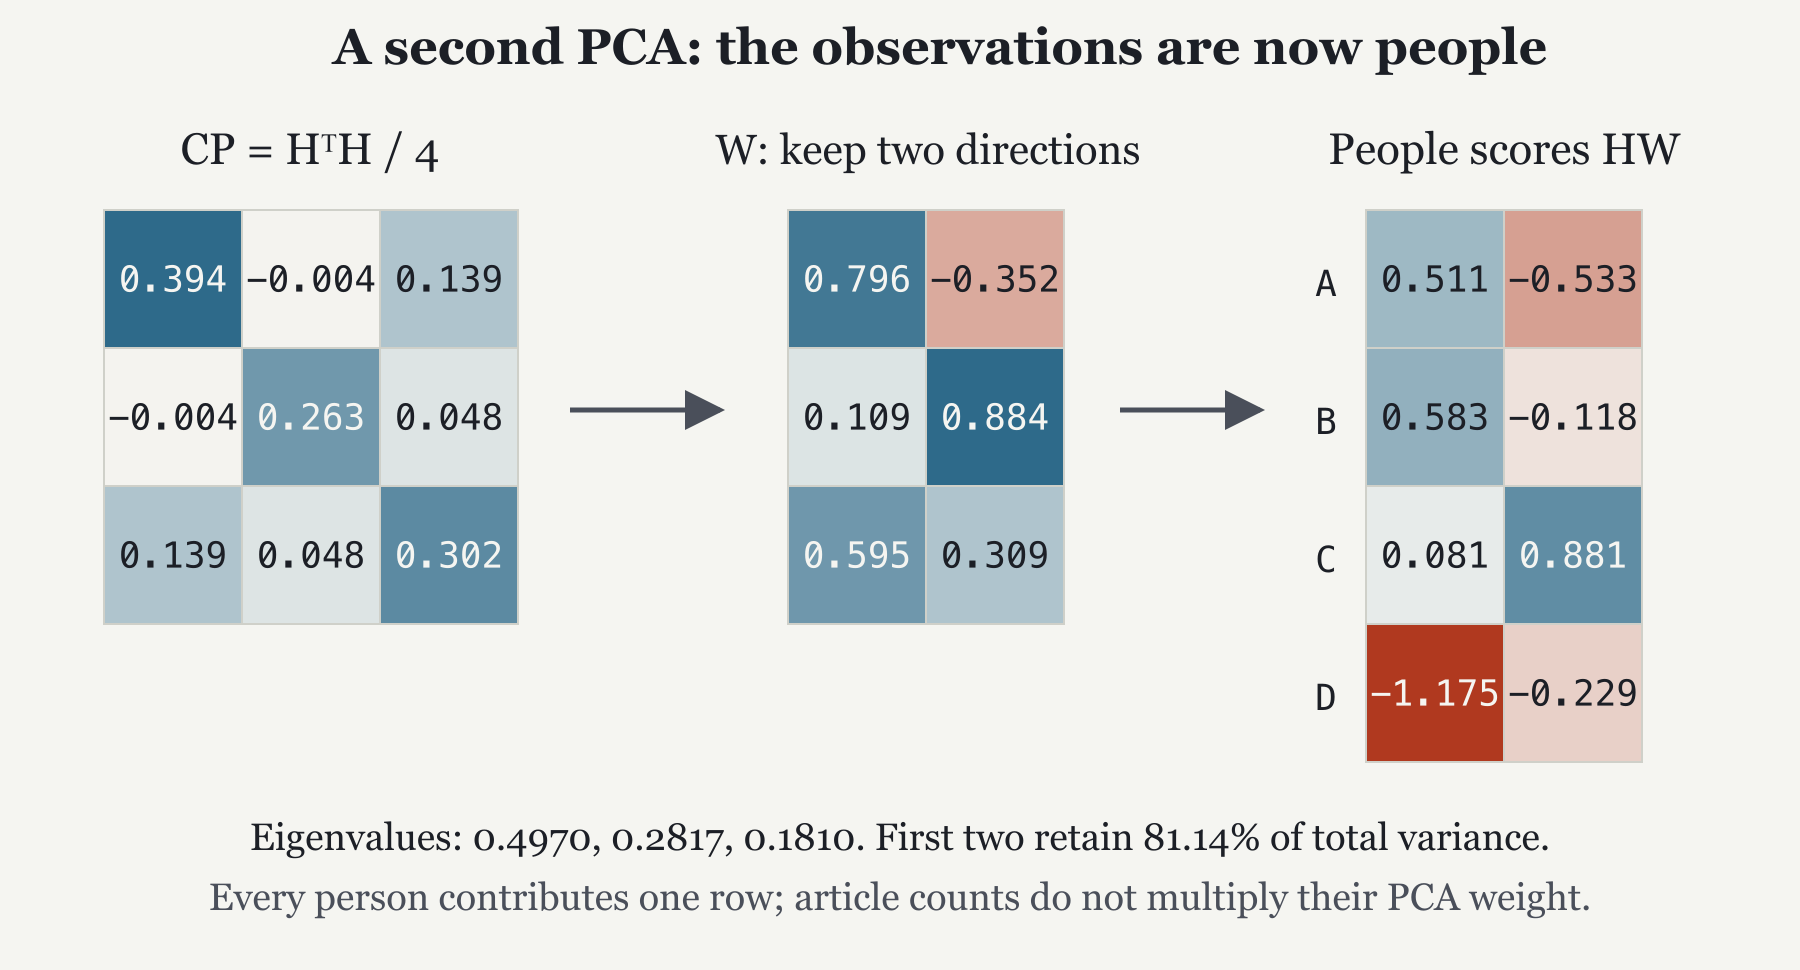

*Unit person profiles are centered, their covariance is decomposed, and two retained directions give each person two scores. The discarded third eigenvalue is visible rather than silently erased.*

### Laboratory: Fit directions and measure retained variance

`eigenvalues` lists covariance eigenvalues from largest to smallest, and
`directions` stores the corresponding unit eigenvectors as columns.
Their signs follow the book's convention: the largest absolute entry in
each column is positive. `loading` retains the first two columns. The
retained fraction sums their eigenvalues and divides by the sum of all
three; it is a population variance fraction, not an individual accuracy.

In [11]:
eigenvalues, directions = oriented_eigh(people_cov)
loading = directions[:, :2]
retained_fraction = eigenvalues[:2].sum() / eigenvalues.sum()
assert_close(people_cov @ directions, directions * eigenvalues)
assert_close(loading.T @ loading, np.eye(2))
assert_close(eigenvalues, [.497006828898,.281673345829,.180965405729])
record_result("retained_fraction", retained_fraction)
for j,value in enumerate(eigenvalues):
    record_result(f"eigenvalue_{j+1}", value)
print("Directions:\n", directions, "\nRetained fraction:", retained_fraction)

retained_fraction = 0.811424749497
eigenvalue_1 = 0.497006828898
eigenvalue_2 = 0.281673345829
eigenvalue_3 = 0.180965405729
Directions:
 [[ 0.796358 -0.351636 -0.492103]
 [ 0.109041  0.883767 -0.455044]
 [ 0.594915  0.308718  0.742138]] 
Retained fraction: 0.8114247494967142


## Locate a person on the patterns

Let $u_p$ denote person $p$'s $1\times r$ people-coordinate row. Project its centered profile $h_p$ onto the retained columns:

$$u_p=h_pW=(b_p-\bar b)W.$$

For A, the first coordinate is approximately

$$0.3411(0.7964)-0.6500(0.1090)+0.5213(0.5949)=0.5109.$$

The second uses the second column of $W$. The resulting rows are:

| Person | P1 score | P2 score |
|---|---:|---:|
| A | 0.5109 | -0.5334 |
| B | 0.5828 | -0.1178 |
| C | 0.0813 | 0.8807 |
| D | -1.1750 | -0.2294 |

P1 is a pattern, not person D, although D has the largest absolute P1 score in this small example. A negative score identifies the other pole of a direction. It does not say that D is opposed to the other people.

In the published models, there are 60 news coordinates and at most 24 directions with positive eigenvalues. The 217-person Hacker News model retains 84.54% of between-person variance; the 61-person general-news model retains 90.86%. These separately fitted percentages should not be read as a contest between corpora. There is no second varimax naming step and no whitening of people scores. The people directions are orthonormal in standardized news coordinates, not generally when mapped back into the original embedding geometry.

### Laboratory: Compute each person's coordinates

`scores` is the four-by-two matrix obtained by projecting centered profile
rows `h` on the retained loading columns. Its columns are P1 and P2.
These scores are not whitened and need not have unit row length.

In [12]:
scores = h @ loading
assert_close(scores, [[.510927818707,-.533436805153],[.582784923304,-.117826825740],
                     [.081330715703,.880691829724],[-1.175043457714,-.229428198831]])
assert_close(scores.T @ scores / 4, np.diag(eigenvalues[:2]))
record_result("A_people_P1", scores[0,0])
record_result("D_people_P1", scores[3,0])
print("A–D people coordinates (P1, P2):\n", scores)

A_people_P1 = 0.510927818707
D_people_P1 = -1.17504345771
A–D people coordinates (P1, P2):
 [[ 0.510928 -0.533437]
 [ 0.582785 -0.117827]
 [ 0.081331  0.880692]
 [-1.175043 -0.229428]]


<a id="two-entrances"></a>

# One loading table has two entrances

## Start with a news axis

The first row of the toy $W$ is $(0.7964,-0.3516)$. It tells us how N1 loads on P1 and P2. Starting from N1, the interface can rank people patterns by the absolute sizes of those two entries. P1 comes first, with a positive loading; P2 comes second, with a negative loading.

## Start with a people pattern

The first column of $W$ is $(0.7964,0.1090,0.5949)^{\mathsf T}$. It tells us how P1 combines N1, N2, and N3. Starting from P1, the interface ranks news axes by the absolute sizes of these entries: N1, then N3, then N2.

The coefficient linking N1 and P1 is exactly the same number in both views. No second model is needed to construct the reverse index. One index exposes rows of $W$; the other exposes columns.

For the diagram, let $j$ index news axes, $\ell$ retained people patterns, $p$ people, and $a$ articles. The scalar $W_{j\ell}$ is row $j$, column $\ell$ of $W$; $z_{aj}$ and $b_{pj}$ are coordinate $j$ of the article and person-profile rows; $u_{p\ell}$ is coordinate $\ell$ of the people-score row. The diagram uses parentheses for these same indices: for example, $W(j,\ell)$ means $W_{j\ell}$. Magnitude means absolute value, so either sign can produce a large magnitude.

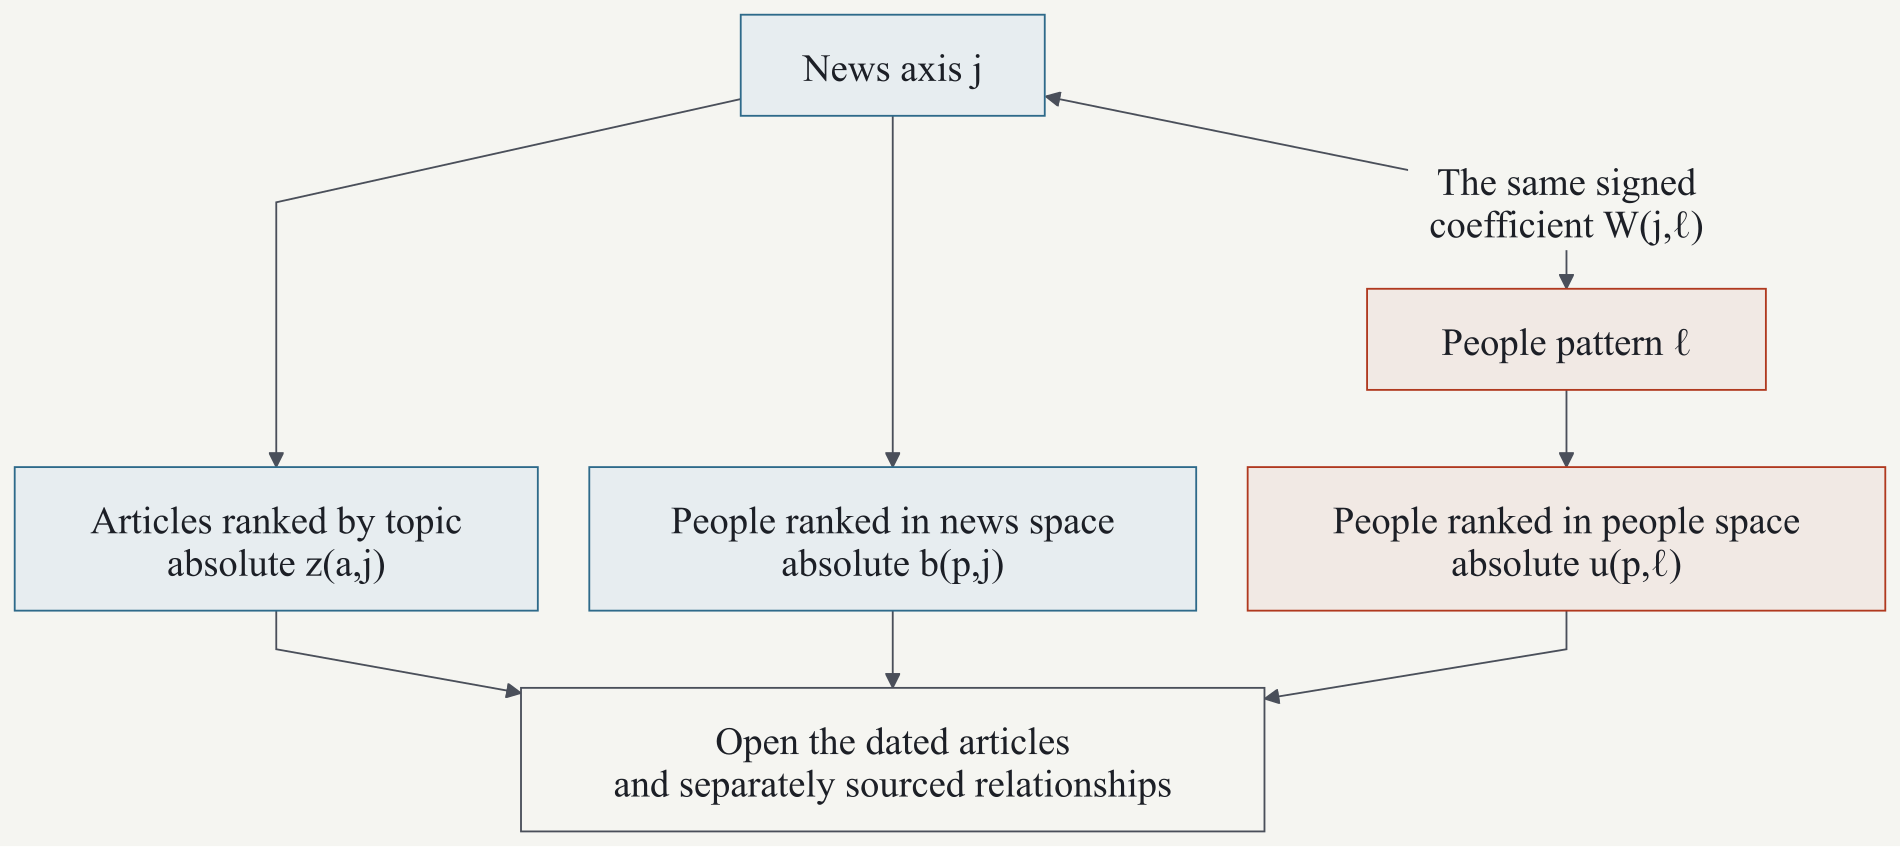

*A row of W answers news-to-pattern questions. A column answers pattern-to-news questions. The signed coefficient is shared, while each ranking compares a different set.*

This does not make ranks reciprocal. N3's strongest loading is P1, but N3 is only the second strongest news loading of P1. Nor are the entries probabilities. Some are negative, and the absolute values in a row or column need not sum to one.

## People can be ranked in two distinct ways

Starting from news axis N1, one can rank people by their direct profile coordinate $|b_{p1}|$. B comes first in the toy example, with 0.9484. This asks whose normalized relative coverage extends farthest along N1, considering either pole.

Starting from people pattern P1, one can instead rank people by $|u_{p1}|$. D comes first, with 1.1750. This asks whose *centered* profile extends farthest along that learned combination of news coordinates.

Those rankings differ because the questions differ. Neither is the same as finding the nearest neighbor of a selected person, which uses the entire row of people scores. A useful interface names the selected axis, mode, pole, model, and time window so a reader knows which question produced the list.

The audited Hacker News model supplies a real example. The loading joining news axis N56 to people pattern P19 is $+0.4144960629$ in both stored indexes. N56's terms include `develop`, `interview`, `databas`, `ceo`, `manag`, and `github`. The shared coefficient is a precise navigation fact. Calling it “the database CEO axis” would discard the mixed meaning of the direction and the evidence needed to identify a current CEO.

**Check 5.** In the toy matrix, N3 ranks P1 first. Where does P1 rank N3? Explain why the two answers are consistent.

### Laboratory: Walk one loading table in both directions

`news_to_people` ranks people patterns by absolute loadings in a selected
news row; `people_to_news` ranks news axes in a selected people column.
We use zero-based indices in code and add one for displayed N/P labels.
`direct_order` ranks people by their full profile's N1 coordinate, while
`pattern_order` ranks them by P1. Absolute magnitude includes both poles.

In [13]:
news_to_people = lambda j: np.argsort(-np.abs(loading[j]))
people_to_news = lambda ell: np.argsort(-np.abs(loading[:,ell]))
print("N1 → P:", news_to_people(0) + 1)
print("P1 → N:", people_to_news(0) + 1)
assert list(people_to_news(0)) == [0,2,1]
assert news_to_people(2)[0] == 0 and people_to_news(0)[1] == 2
direct_order = np.argsort(-np.abs(b[:,0]))
pattern_order = np.argsort(-np.abs(scores[:,0]))
assert people[direct_order[0]] == "B"
assert people[pattern_order[0]] == "D"
record_result("N1_P1_loading", loading[0,0])
print("Direct N1 people:", [people[i] for i in direct_order])
print("P1 people:", [people[i] for i in pattern_order])

N1 → P: [1 2]
P1 → N: [1 3 2]
N1_P1_loading = 0.796358235918
Direct N1 people: ['B', 'D', 'A', 'C']
P1 people: ['D', 'B', 'A', 'C']


### Laboratory: Check the dated reciprocal-index entry

**Frozen evidence from the book, not a reconstructed model:** the audited
loading joining news axis N56 to people pattern P19 is +0.4144960629.
`dated_by_news` and `dated_by_people` materialize the two lookup directions
for that supplied entry. Their equality checks index semantics only;
the complete published model would be needed to verify every stored entry.
Its stems mix development, interviews, databases, CEOs, management, and
GitHub; a numerical route does not establish a clean “database CEO” label.

In [14]:
dated_loading_entry = (56,19,.4144960629)
dated_by_news = {56:{19:dated_loading_entry[2]}}
dated_by_people = {19:{56:dated_loading_entry[2]}}
assert_close(dated_by_news[56][19],dated_by_people[19][56])
record_result("dated_N56_P19_loading",dated_by_news[56][19])
print("DATED mixed stems:", ["develop","interview","databas","ceo","manag","github"])

dated_N56_P19_loading = 0.4144960629
DATED mixed stems: ['develop', 'interview', 'databas', 'ceo', 'manag', 'github']


<a id="round-trip"></a>

# Returning through the map loses detail

## The return operation

When discussing one person without naming them, write $b$, $h$, and $u$ for their unit profile $b_p$, centered profile $h_p$, and retained score row $u_p$. The rows $b,h$ have $K$ coordinates and $u$ has $r$. Let $\hat h$ be the $1\times K$ reconstruction of $h$; the hat denotes an approximation returned from retained coordinates. After calculating $u=hW$, multiply by the transpose:

$$\hat h=uW^{\mathsf T}=hWW^{\mathsf T}.$$

Adding $\bar b$ gives the corresponding reconstruction of the unit news profile. It does not give back the original articles.

An orthogonal projector keeps a vector's component in a chosen subspace and discards its perpendicular component. Let $P$ be the $K\times K$ forward-and-return matrix, defined by $P=WW^{\mathsf T}$. A symmetric matrix equals its transpose; an idempotent matrix has the same effect when applied twice as once. Because the columns of $W$ are orthonormal, $P$ has both properties:

$$P^{\mathsf T}=P,\qquad P^2=W(W^{\mathsf T}W)W^{\mathsf T}=P.$$

The first equality expresses symmetry and the second idempotence. Together these identify an orthogonal projector. Once a row lies in the retained plane, projecting it onto that plane again changes nothing.

The residual is the difference between the original centered row and its reconstruction, $h-\hat h$. It is perpendicular to the retained directions. Consequently,

$$\lVert h\rVert^2=\lVert \hat h\rVert^2+\lVert h-\hat h\rVert^2.$$

This is the familiar right-triangle rule, now applied to components of a vector. In the fitted toy example, A's discarded squared length is approximately 0.2650. The example script checks the decomposition and the orthogonality of the residual using unrounded values.

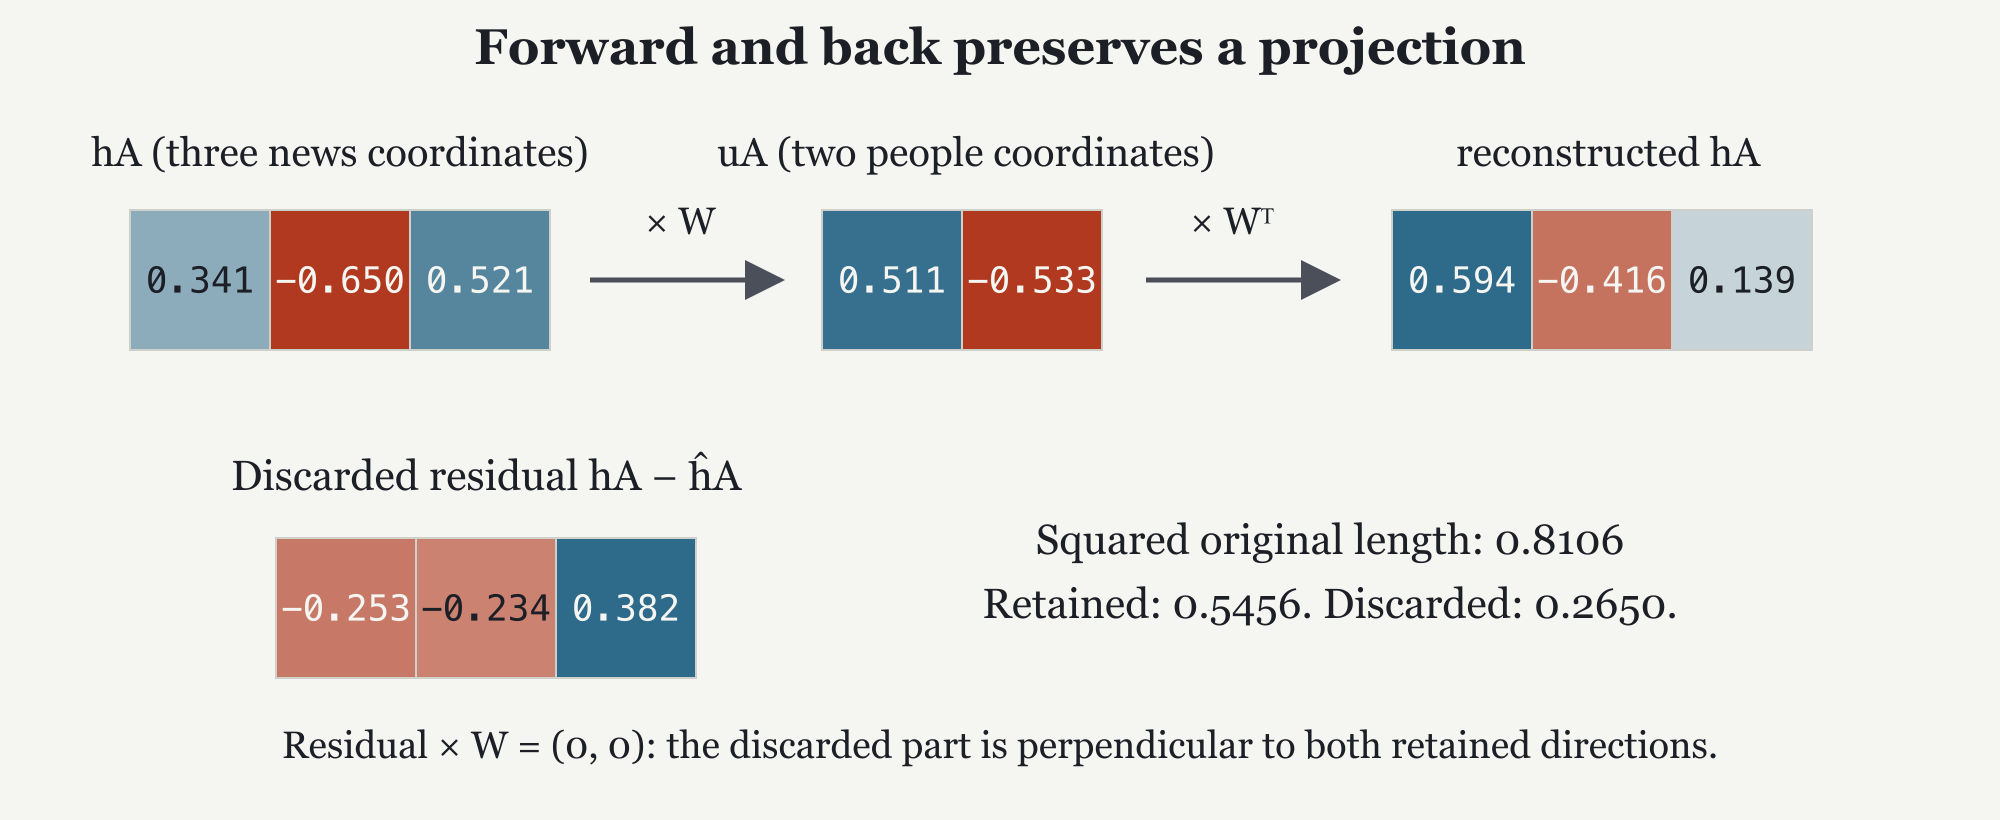

*Projecting a centered profile onto two people directions and returning reconstructs only its component in their plane. The residual is a measurable part of the original profile.*

### Laboratory: Compute the round trip and each person's lost energy

`projector` is the three-by-three matrix `loading × loadingᵀ`.
`reconstruction` returns people scores to centered news coordinates;
`discarded` is the remaining orthogonal residual. `lost_energy` and
`full_energy` are squared row lengths; their ratio gives each person's
loss. `query` is the unit N1 row, whose round trip returns only its
projection into the retained subspace.

In [15]:
projector = loading @ loading.T
reconstruction = scores @ loading.T
discarded = h - reconstruction
lost_energy = np.sum(discarded**2, axis=1)
full_energy = np.sum(h**2, axis=1)
assert_close(projector, projector.T)
assert_close(projector @ projector, projector)
assert_close(discarded @ loading, np.zeros((4,2)))
assert_close(np.sum(scores**2, axis=1) + lost_energy, full_energy)
assert_close(lost_energy.sum(), 4 * eigenvalues[2])
query = np.array([1.,0.,0.])
query_coordinates = query @ loading
returned_query = query_coordinates @ loading.T
assert_close(returned_query, [.757834375106,-.223928644616,.365208703530])
record_result("A_discarded_energy", lost_energy[0])
record_result("B_individual_retained", 1 - lost_energy[1]/full_energy[1])
record_result("roundtrip_N1", returned_query[0])
print("Projector:\n", projector, "\nPer-person retained fraction:", 1-lost_energy/full_energy)
print("N1 → people → news:", query_coordinates, "→", returned_query)

A_discarded_energy = 0.265029520461
B_individual_retained = 0.462825953083
roundtrip_N1 = 0.757834375106
Projector:
 [[ 0.757834 -0.223929  0.365209]
 [-0.223929  0.792935  0.337706]
 [ 0.365209  0.337706  0.449231]] 
Per-person retained fraction: [0.673058 0.462826 0.948836 0.995595]
N1 → people → news: [ 0.796358 -0.351636] → [ 0.757834 -0.223929  0.365209]


## An even smaller exact example

To see the loss without decimals, set aside the fitted toy matrix for a moment. Let $W_*$ denote this deliberately chosen $3\times2$ matrix; the star distinguishes it from the fitted $W$:

$$W_* = \begin{pmatrix}1/\sqrt2&0\\1/\sqrt2&0\\0&1\end{pmatrix}.$$

This is an illustration, not another fit. It retains the shared direction of the first two coordinates and retains the third coordinate separately. A query $h=(1,0,0)$ goes forward to $(1/\sqrt2,0)$ and returns as $(1/2,1/2,0)$. The first-versus-second distinction was discarded.

A linear map preserves addition and scaling; multiplication by a fixed matrix is an example. An adjoint transfers a linear map to the other side of a dot product; for real matrices with Euclidean dot products, it is the transpose. Least squares means minimizing the sum of squared coordinate discrepancies. A Moore-Penrose pseudoinverse is a generalized inverse that gives least-squares solutions, choosing the shortest solution when several are possible. Because $W$ has orthonormal columns, $W^{\mathsf T}$ is both its adjoint and its pseudoinverse. It returns the least-squares reconstruction of a centered profile in the retained subspace. A two-sided inverse would undo the map in both directions for every input; this transpose cannot do that. With 24 retained directions out of 60, there is no way to recover every possible original 60-coordinate row.

### Laboratory: Show two different inputs with the same return

The two columns of `exact_loading` are (1/√2,1/√2,0) and (0,0,1).
The unit rows `first_axis` and `second_axis` differ, but their projections
coincide. The lost direction (1,−1,0) is orthogonal to both columns.

In [16]:
exact_loading = np.array([[1/np.sqrt(2),0],[1/np.sqrt(2),0],[0,1]])
first_axis, second_axis = np.eye(3)[:2]
assert_close(first_axis @ exact_loading, second_axis @ exact_loading)
exact_return = first_axis @ exact_loading @ exact_loading.T
assert_close(exact_return, [.5,.5,0])
assert_close((first_axis-second_axis) @ exact_loading, np.zeros(2))
record_result("exact_return_N1", exact_return[0])
print("Both axes return as", exact_return)

exact_return_N1 = 0.5
Both axes return as [0.5 0.5 0. ]


## Loss began before this projection

Even retaining every people direction would not recover an article list from a person profile. The earlier pipeline also reduced a 384-coordinate embedding to 60 news coordinates, averaged articles, subtracted backgrounds, and normalized lengths. Many different inputs can give the same output after those operations.

Navigation is valuable without being invertible. It provides linked views of a representation and routes back to stored evidence. The article links and factual sources are retained separately precisely because the vector cannot reconstruct them.

## Why the singular value decomposition gives two views

Singular value decomposition (SVD) factors a matrix into two sets of orthonormal directions and nonnegative scale factors called singular values. For a longer prerequisite, revisit [the Eigen Times SVD chapter](https://firstpair.org/read/eigentimes-math/chapters/chapter-007.html#what-the-svd-is). The operator $\min$ selects the smaller of two numbers. For the centered $n\times K$ matrix $H$, let $k_* = \min(n,K)$. In the thin decomposition, $U$ is an $n\times k_*$ matrix of left directions, indexed by people, and $Q$ is a $K\times k_*$ matrix of right directions, indexed by news coordinates. Both have orthonormal columns. Let $\Sigma$ be the $k_*\times k_*$ diagonal matrix of singular values in descending order. Then

$$H=U\Sigma Q^{\mathsf T}.$$

Recall that $r$ counts retained positive people directions. Let $U_r$ and $Q_r$ contain the first $r$ columns of their respective matrices, and let $\Sigma_r$ contain the leading $r\times r$ diagonal block of $\Sigma$. Thus $U_r$ has shape $n\times r$ and $Q_r$ shape $K\times r$. Using the same ordering and orientation as the people eigendecomposition gives $W=Q_r$ and

$$HW=U_r\Sigma_r.$$

The scores include the singular values; they are not just the columns of $U_r$. Each squared singular value divided by $n$ equals the corresponding eigenvalue of the earlier people covariance. The right directions come from $H^{\mathsf T}H$, while the left directions come from $HH^{\mathsf T}$. These are two sides of the same centered profile matrix. An adjacency matrix instead records which graph nodes have edges between them. Neither calculation uses that matrix from Anthropology's relationship graph. A graph community is a group of nodes relatively densely linked to one another. Communities and people patterns can be interesting to compare, but they are not the same construction.

**Check 6.** For $W_*$ above, project $h=(0,1,0)$ forward and back. Compare its returned row with the return from $(1,0,0)$. What information can the map no longer distinguish?

### Laboratory: Compute SVD, not just its formula

`svd_u`, `singular_values`, and `svd_v` factor the centered table `h` as
UΣVᵀ (the book names the last factor Q). Python uses a direct SVD; OCaml
uses a native symmetric Jacobi eigensolver on the small Gram matrix HᵀH,
then computes U from H V / σ. This Gram method is for tiny teaching
fixtures and is less numerically robust than a production direct SVD.
Sign alignment makes the first two right vectors agree with `loading`.
We check reconstruction, λ=σ²/4, and scores=UΣ rather than U alone.

In [17]:
svd_u, singular_values, svd_vt = np.linalg.svd(h, full_matrices=False)
svd_v = svd_vt.T
for j in range(3):
    if svd_v[:,j] @ directions[:,j] < 0:
        svd_u[:,j] *= -1
        svd_v[:,j] *= -1
assert_close(svd_u @ np.diag(singular_values) @ svd_v.T, h)
assert_close(singular_values**2 / 4, eigenvalues)
assert_close(svd_u[:,:2] * singular_values[:2], scores)
assert_close(svd_v[:,:2], loading)
record_result("first_singular_value", singular_values[0])
print("Singular values:", singular_values, "\nU:\n", svd_u)

first_singular_value = 1.40997422515
Singular values: [1.409974 1.061458 0.850801] 
U:
 [[ 0.362367 -0.502551  0.605089]
 [ 0.41333  -0.111005 -0.752885]
 [ 0.057682  0.8297    0.241393]
 [-0.833379 -0.216144 -0.093597]]


<a id="neighbors"></a>

# Finding neighbors without inventing relationships

## Compare complete rows in one coordinate system

Here $p$ and $q$ index two people, and $u_p,u_q$ are their nonzero $1\times r$ score rows from the same model and coverage window. The person index $q$ is distinct from a background row such as $q_g$. Cosine similarity, written $\operatorname{cos}(u_p,u_q)$, is their dot product divided by the product of their lengths:

$$\operatorname{cos}(u_p,u_q)=\frac{u_p\cdot u_q}{\lVert u_p\rVert\,\lVert u_q\rVert}.$$

It compares direction rather than length and is undefined if either row is zero. A value near 1 means similarly directed rows, 0 means perpendicular rows, and -1 means opposite directions in the specified centered representation. Negative similarity is not evidence of competition, disagreement, or hostility.

Anthropology's neighbor view uses complete retained people-score rows within the same model and window. Do not mix a recent profile from one model with an all-history profile from another and call their raw dot product a meaningful similarity. Even matching dimensions are insufficient: the coordinates must share their meanings.

## Compression can change the answer substantially

The toy example makes the danger visible. A and B have a cosine of only 0.0392 between their full centered three-coordinate profiles. Their cosine becomes 0.8211 after projection into the two retained people directions.

No arithmetic error occurred. The discarded direction contained much of their difference. The retained plane makes them look more alike. Keeping 81.14% of the population's total variance did not preserve every pairwise angle.

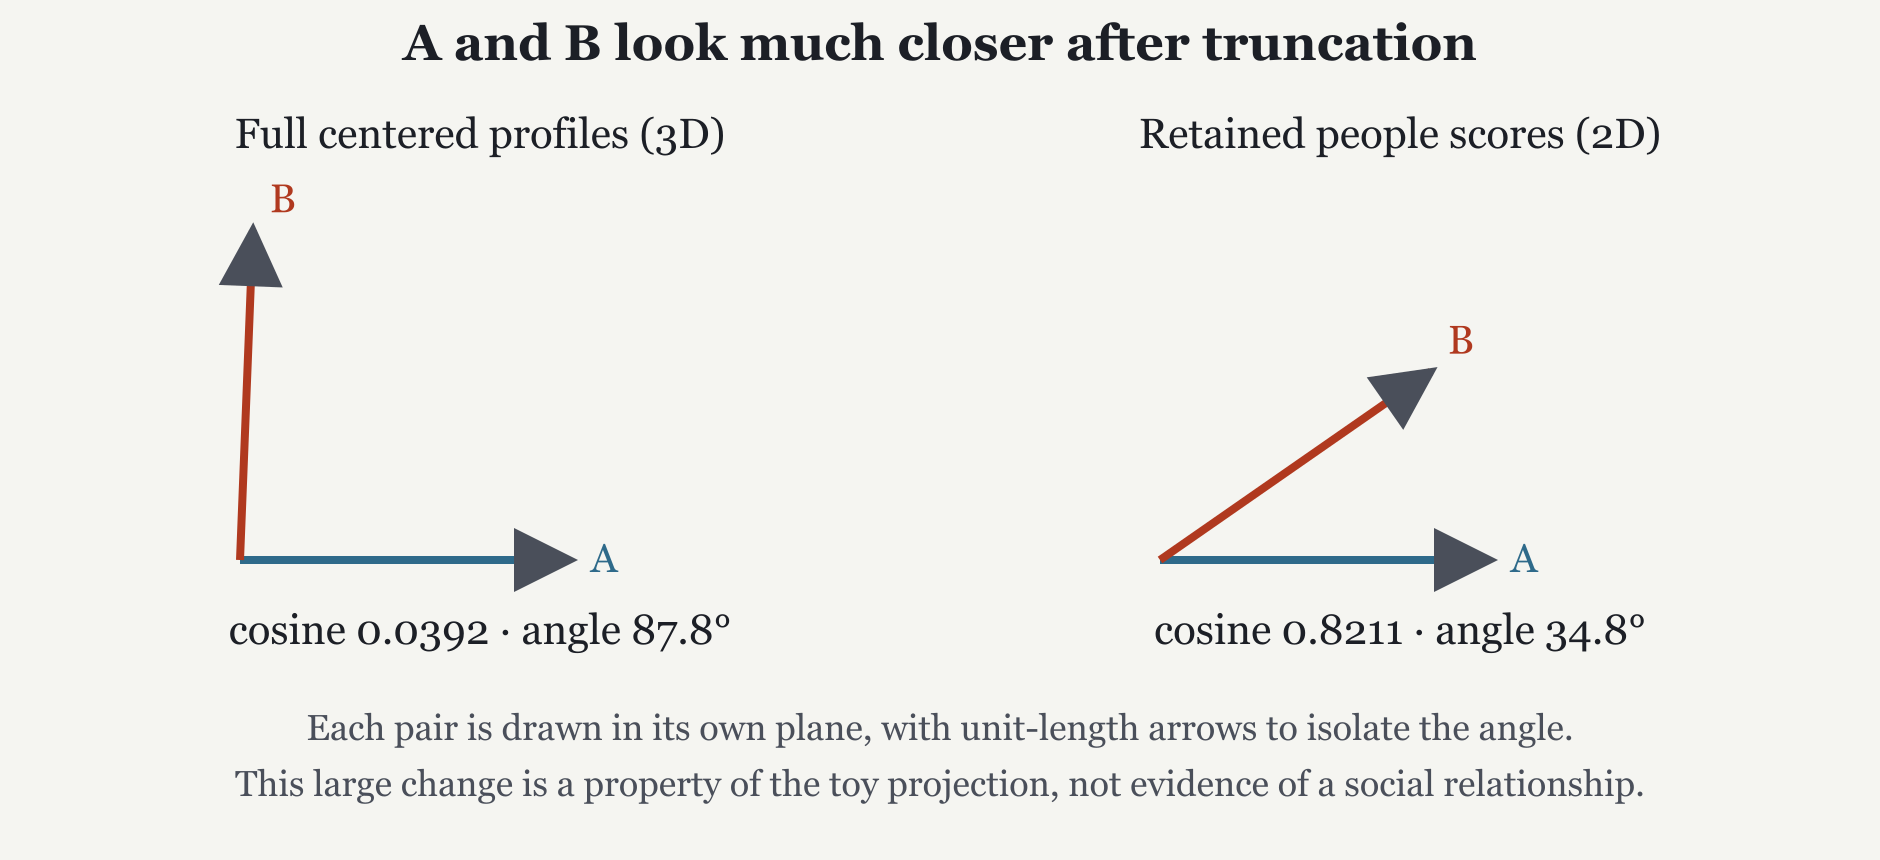

*Cosines before and after retaining two people directions. A and B demonstrate why a strong reduced-space neighbor score needs a full-space baseline.*

The same check is useful in the real model. In the frozen Hacker News model, LeCun and Bengio have a retained-space cosine of 0.9587 and a full centered news-space cosine of 0.9118. Ellison and Siebel have 0.7198 and 0.5800 respectively, with 416 and 11 candidate articles. These values describe this corpus and representation; the much smaller support for one member deserves attention.

An appealing analogy can also fail. Zuckerberg and Gates have retained-space cosine 0.0782 in Hacker News and -0.1137 in the separate general-news model. Being prominent technology founders does not require the archives to cover them in the same way. A research system should let the evidence correct the analogy.

### Laboratory: Compute all six neighbor comparisons

`full_cosine` compares centered three-dimensional rows; `reduced_cosine`
compares their retained two-dimensional scores. Every unordered pair of
the four fictional people is computed. The last assertion tests—and
rejects—the proposed guarantee that population retained variance bounds
every pair's cosine distortion. Similarity still supplies no typed edge.

In [18]:
pair_cosines = []
for i in range(4):
    for j in range(i+1,4):
        full_cosine = cosine(h[i],h[j])
        reduced_cosine = cosine(scores[i],scores[j])
        pair_cosines.append((people[i]+people[j],full_cosine,reduced_cosine))
        print(people[i]+people[j], "full =", round(full_cosine,6), "retained =", round(reduced_cosine,6))
ab_full, ab_reduced = pair_cosines[0][1:]
assert_close(ab_full, .039205113954)
assert_close(ab_reduced, .821101689712)
assert abs(ab_reduced-ab_full) > 1-retained_fraction
record_result("AB_full_cosine", ab_full)
record_result("AB_reduced_cosine", ab_reduced)

AB full = 0.039205 retained = 0.821102
AC full = -0.39451 retained = -0.655512
AD full = -0.480392 retained = -0.540494
BC full = -0.236819 retained = -0.107196
BD full = -0.5786 retained = -0.924027
CD full = -0.288197 retained = -0.281073
AB_full_cosine = 0.0392051139537
AB_reduced_cosine = 0.821101689712


## What a neighbor score leaves unresolved

Two profiles can be close because the same articles mention both people, because different articles discuss similar subjects, or because the archive repeatedly frames them in a similar way. A cosine alone cannot distinguish these explanations. One useful sensitivity analysis would remove their shared articles and recompute the comparison. That experiment was proposed in the paper; it was not part of the published evaluation.

For a nonzero centered row $h$, retained energy is the fraction of its squared length preserved by projection, $\lVert hW\rVert^2/\lVert h\rVert^2$. Support counts, full-space baselines, retained energy, dates, and example articles help a reader interpret a score. Calibration means agreement between predicted probabilities and observed frequencies. These aids do not turn a neighbor score into a calibrated probability of collaboration. A documented relationship still requires its own source. The named examples here demonstrate navigation, not a statistically representative assessment of retrieval quality.

**Check 7.** Does retaining 81.14% of total variance guarantee that every neighbor cosine changes by less than 18.86 percentage points? Use A and B to test the claim.

<a id="time"></a>

# People can move while the map stays fixed

## Reuse the ruler

A person can receive different coverage this year than ten years ago. We want to observe that movement without changing the ruler at the same time. Let $w$ index a coverage window, such as a decade or a recent period. Write $b_{pw}$ for person $p$'s $1\times K$ unit profile built from that window's eligible articles, and $u_{pw}$ for its $1\times r$ people-coordinate row. A comma in $u_{p,w}$ separates the same indices without changing their meaning. Fit the people mean $\bar b$ and loading matrix $W$ once on the all-history profiles, then use them for every supported window:

$$u_{pw}=(b_{pw}-\bar b)W.$$

The article associations, supported cells, cell means, and cell backgrounds are recomputed for that window. Write $m_{pgw}$ for person $p$'s cell-$g$ mean in window $w$, and $q_{gw}$ for that cell's background mean, both $1\times K$ rows. They use the same averaging rule as before, restricted to articles in the window. The people mean and directions remain the fitted all-history reference.

This makes score differences interpretable within a model version. Let $w_1$ and $w_2$ be two supported windows for the same person, and let $\Delta_p$ denote the Euclidean distance between that person's two score rows. A simple movement statistic is

$$\Delta_p=\lVert u_{p,w_2}-u_{p,w_1}\rVert.$$

It is a distance between two supported coverage profiles. It is not, by itself, a measure of a person's career change. A source mix can change, a name attribution can be corrected, or the comparison background can shift.

## Separate movement from a change of mixture

Return to A's two cell contrasts. Hold both contrasts fixed, but consider two synthetic count mixtures: 90:10 and 10:90. These are a sensitivity experiment, not two additional observed periods in the 45-article corpus. In each mixture both cells satisfy the support threshold.

Weighting the contrasts by those counts, normalizing, and applying the same fitted mean and $W$ gives people scores of approximately $(0.696,-0.459)$ in the first mixture and $(0.389,-0.547)$ in the second. Their apparent movement is about 0.319. Yet neither cell-specific contrast changed.

Equal supported-cell weighting keeps A at its original people coordinates $(0.5109,-0.5334)$ in both mixtures. This illustrates one composition effect the balancing rule can reduce; it does not establish invariance to changes in the actual within-cell article distributions.

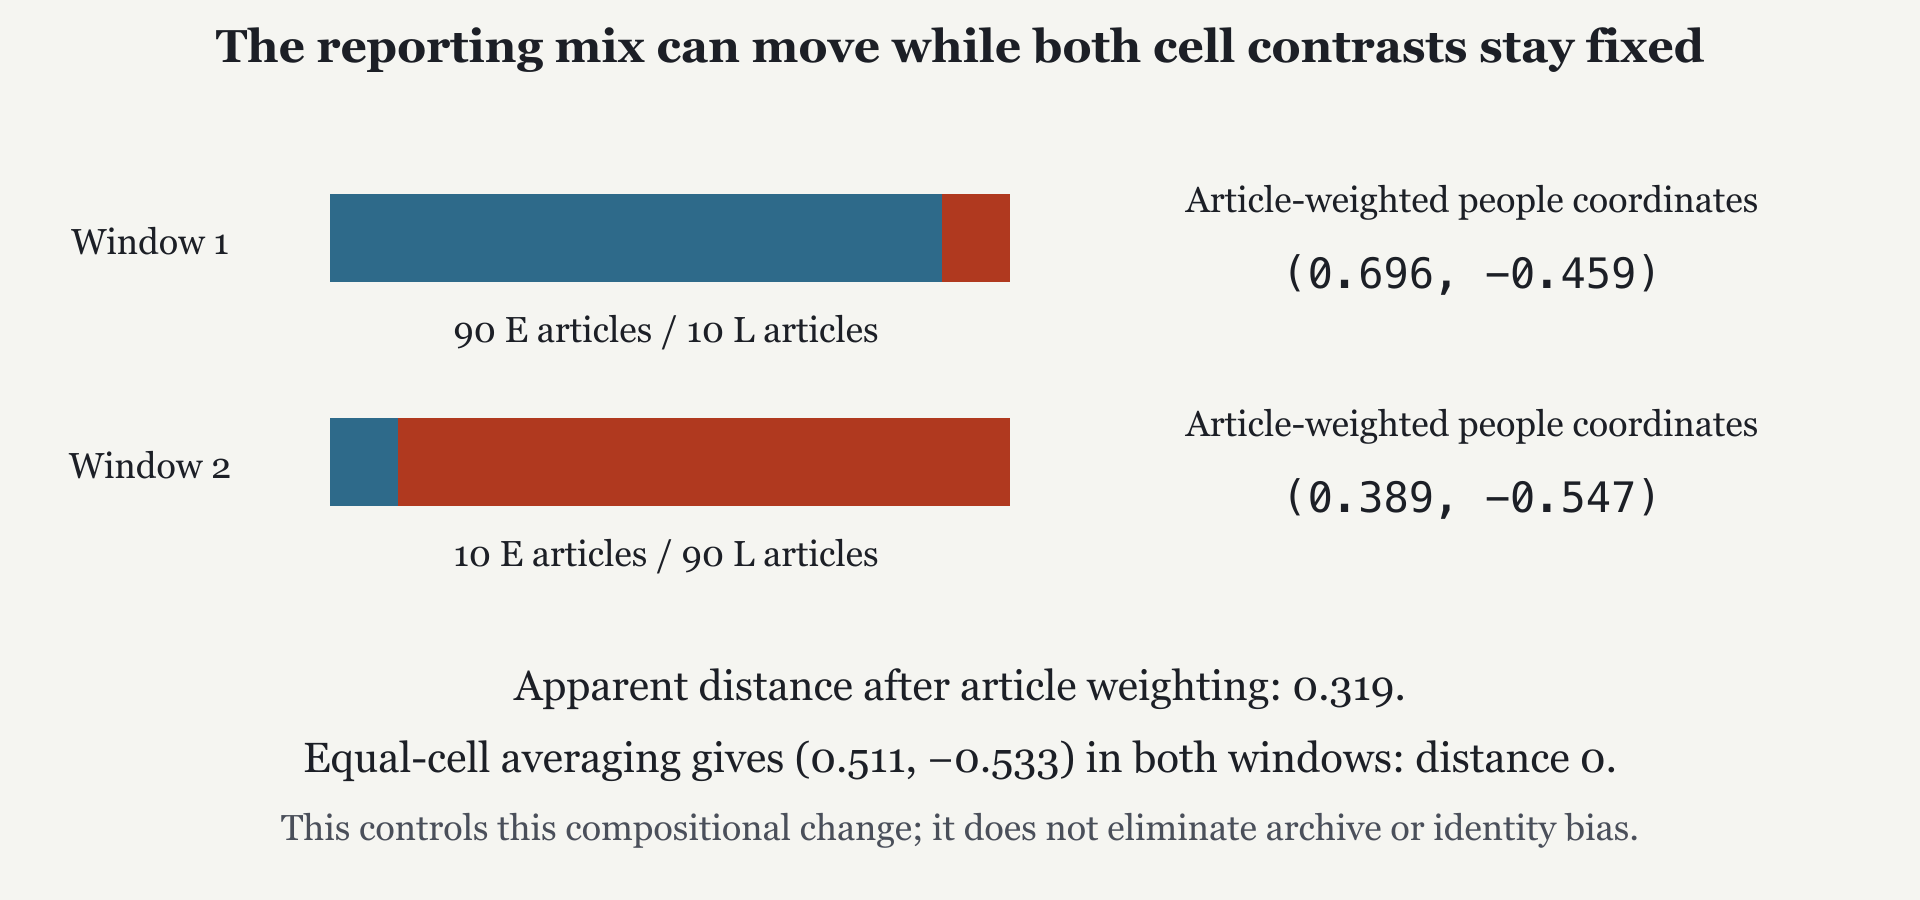

*A change in article mixture can move an article-weighted profile even when its within-cell contrasts are fixed. Equal-cell weighting removes this particular movement, provided both cells remain supported.*

It does not remove every composition effect. If a cell falls below the support threshold, the retained set changes. If $q_{gw}$ changes, a person's contrast changes even if its own articles do not. Two points can be drawn in one coordinate frame while still differing in their comparison backgrounds.

### Laboratory: Hold the contrasts fixed and change only the counts

`mixtures` contains the two synthetic early/late count pairs (90,10) and
(10,90). `weighted_scores` normalizes each article-weighted contrast and
projects it with the **same fitted** people mean and loadings. In
`balanced_scores`, equal supported-cell averaging holds the result fixed.
The earlier gate test also shows why crossing from four to five articles
can still move an equal-cell profile.

In [19]:
mixtures = np.array([[90,10],[10,90]])
weighted_residuals = np.array([np.average(contrasts[0],axis=0,weights=mix) for mix in mixtures])
weighted_scores = (np.array([unit(row) for row in weighted_residuals])-people_mean) @ loading
balanced_scores = np.array([(unit(balanced_profile(mix,contrasts[0],sum(mix)))-people_mean) @ loading for mix in mixtures])
weighted_movement = np.linalg.norm(weighted_scores[1]-weighted_scores[0])
balanced_movement = np.linalg.norm(balanced_scores[1]-balanced_scores[0])
assert_close(weighted_movement,.318752257891)
assert_close(balanced_movement,0)
assert_close(balanced_scores[0],scores[0])
record_result("mixture_weighted_movement", weighted_movement)
record_result("mixture_balanced_movement", balanced_movement)
print("Weighted scores:\n", weighted_scores, "\nBalanced scores:\n", balanced_scores)

mixture_weighted_movement = 0.318752257891
mixture_balanced_movement = 0
Weighted scores:
 [[ 0.695803 -0.459252]
 [ 0.389246 -0.546577]] 
Balanced scores:
 [[ 0.510928 -0.533437]
 [ 0.510928 -0.533437]]


## Three clocks and a model version

An article's publication date is one clock. The newest matched article used in a historical profile is another. The valid date of a documented role is a third. A fourth piece of context, the model version, identifies the numerical ruler rather than a date of an event.

The projection watermark records the latest article date represented in the local projected corpus. In the frozen people snapshot, matched profiles end on 4 September 2026 and the local projection watermark is 5 September. The current-news overlay is dated 1 October. Recent-36-month and latest-90-day profile windows are anchored to the builder's latest matched article date, not automatically to the reader's present clock. Publishing a larger identity catalog on 2 October did not refit those profiles or update every watermark.

An absent recent profile means insufficient supported coverage. It must not be plotted at the origin as if it were evidence that the person became average.

## How a future incremental refresh could work

For each person-cell-window, let $N_{pgw}$ count its distinct eligible associated articles, and let $S_{pgw}$ be the $1\times K$ sum of their standardized rows $z_a$. For $N_{pgw}>0$, the previously defined person-cell mean is $m_{pgw}=S_{pgw}/N_{pgw}$. These $S$ sums are unrelated to the singular-value matrix $\Sigma$. Keep a separate deduplicated count and sum for the cell background. New qualified articles add to these statistics; expired rolling-window articles subtract from them; corrected attributions remove an old contribution and add the corrected one.

For these mean updates, the count and coordinate sum are sufficient summaries: they retain everything needed to recompute the mean without rereading unchanged articles. The [Eigen Times streaming chapter](https://firstpair.org/read/eigentimes-math/chapters/chapter-013.html#sums-over-blocks) explains this pattern more generally. The added complication here is the shared background: changing one background can require refreshing every person who uses that cell. Updating only the newly mentioned person would leave inconsistent comparisons.

After updating the means, reapply support gates, subtraction, equal-cell averaging, normalization, and the fixed projection. For one resulting supported window, abbreviate its centered profile as $h_p=b_{pw}-\bar b$, suppressing the window index for this calculation. Let $Q_p$ denote its discarded squared length; this scalar is distinct from the SVD's right-direction matrix $Q$. Define the residual statistic as

$$Q_p=\lVert h_p-h_pWW^{\mathsf T}\rVert^2.$$

It measures how much of that centered profile lies outside the retained people subspace. A sustained rise could motivate evaluating a new basis. It is not an automatic alarm that a person changed, and this $Q_p$ uses people-profile geometry rather than silently inheriting every threshold from article-level Eigen Times statistics.

This refresh algorithm is proposed. The deployed latest-news overlay does not perform it. New versions should preserve their predecessors and be evaluated on later observations kept out of fitting, with adequate support and source-sensitive uncertainty checks before making claims about change.

**Check 8.** Can a person's profile change when no new article has been associated with that person? Identify two ways the aggregation can produce that result.

### Laboratory: Execute count-and-sum updates with background fan-out

This is an implementation exercise for the **proposed** refresh algorithm.
`early_sum` and `early_count` summarize unique early-cell articles. A new
unassociated article `new_row` changes the background but no person's
personal mean, so every user of that background must refresh. Subtracting
it restores the old state. `personal_sum` demonstrates correcting an
attribution by removing one old row and adding one replacement. The
final `refreshed_loss` recomputes the discarded squared length in the
frozen people basis; no production refresh is performed here.

In [20]:
early_count = counts[:4].sum()
early_sum = counts[:4] @ z[:4]
new_row = np.array([0.,0.,0.])
updated_count, updated_sum = early_count+1, early_sum+new_row
updated_background = updated_sum/updated_count
assert_close((updated_sum-new_row)/(updated_count-1), backgrounds[0])
updated_contrasts = contrasts.copy()
updated_contrasts[:,0] = cell_means[:,0]-updated_background
updated_b = np.array([unit(rows.mean(axis=0)) for rows in updated_contrasts])
assert np.all(np.linalg.norm(updated_b-b,axis=1)>0)
personal_sum = cell_counts[0,0]*cell_means[0,0]
corrected_sum = personal_sum-z[0]+z[2]
assert_close(corrected_sum-personal_sum,z[2]-z[0])
refreshed_h = updated_b[0]-people_mean
refreshed_loss = np.sum((refreshed_h-refreshed_h@projector)**2)
record_result("updated_early_background_N1", updated_background[0])
record_result("refreshed_A_discarded_energy", refreshed_loss)
print("All four profiles move after background-only update:", np.linalg.norm(updated_b-b,axis=1))
print("Corrected personal sum:", corrected_sum)

updated_early_background_N1 = 0.769230769231
refreshed_A_discarded_energy = 0.260839923028
All four profiles move after background-only update: [0.012797 0.016206 0.008125 0.002138]
Corrected personal sum: [23.  7. 21.]


<a id="attention"></a>

# Relevance and significance answer different questions

## Direction is not attention

A topic coordinate tells us how strongly an article lies along a direction. Eigen significance supplies another scalar: a story's attention score, based on the original story-ranking method. Anthropology keeps that signal alongside the vector rather than silently using it as a weight in the equal-person PCA fit.

The source's story score is allocated to its member articles and normalized by the scored source's total in the relevant period. Let $\alpha_a$ be article $a$'s resulting nonnegative attention share. Recall that $z_{aj}$ is coordinate $j$ of the standardized article row $z_a$. Let $\operatorname{rank}_j(a)$ denote an attention-weighted topic score, not an ordinal position in a list. One selectable latest-article ranking uses

$$\operatorname{rank}_j(a)=|z_{aj}|\alpha_a.$$

The absolute coordinate measures topic strength on either pole; $\alpha_a$ measures allocated attention. The product deliberately answers a combined question. A reader can also choose topic-only ordering or inspect one pole separately.

For a tiny illustration, suppose article X has topic strength 2 and attention share 0.01, while article Y has topic strength 0.5 and attention share 0.10. Topic-only ordering puts X first. The combined scores are 0.02 and 0.05, so attention-weighted ordering puts Y first. Nothing about the topic coordinates changed.

### Laboratory: Compute two deliberately different article rankings

`strength` stores absolute topic coordinates for articles X and Y;
`attention` stores their nonnegative allocated attention shares. Their
product is a score, not an ordinal position or probability. The second
E1/E2/L1 illustration reproduces the accompanying numerical fixture.

In [21]:
article_labels = ["X","Y"]
strength = np.array([2.,.5])
attention = np.array([.01,.10])
combined = strength*attention
assert_close(combined,[.02,.05])
assert np.argmax(strength)==0 and np.argmax(combined)==1
fixture_strength = np.array([2.,1.,1.])
fixture_attention = np.array([.01,.10,.04])
assert_close(fixture_strength*fixture_attention,[.02,.10,.04])
record_result("X_attention_topic_score",combined[0])
record_result("Y_attention_topic_score",combined[1])
print("Topic first:",article_labels[np.argmax(strength)], "; combined first:",article_labels[np.argmax(combined)])
print("E1/E2/L1 combined scores:",fixture_strength*fixture_attention)

X_attention_topic_score = 0.02
Y_attention_topic_score = 0.05
Topic first: X ; combined first: Y
E1/E2/L1 combined scores: [0.02 0.1  0.04]


## Person attention shares can overlap

If a 0.10-share article mentions A and B, that coverage can contribute to both people's attention histories. Their combined credited share can exceed the article's 0.10. These histories describe overlapping coverage, not a partition of total human importance.

Source normalization matters too. Averaging shares over active sources, including sources with no mention of a person, differs from pooling raw scores from a large and a small outlet. State the denominator before interpreting the percentage. The [Eigen Times discussion of story energy and ranking](https://firstpair.org/read/eigentimes-math/chapters/chapter-011.html#energy-1-%CE%BD-for-ranking) provides the deeper article-level background; the person layer adds attribution and aggregation rather than redefining that original significance.

### Laboratory: State the denominator and keep shared coverage shared

`source_totals` gives the total scored attention in two active sources;
`attributed` gives the selected person's attention in each source,
including zero in the second. `active_source_mean` averages source-level
shares; `pooled_share` divides pooled scores. Separately, a single article
with share 0.10 mentions two people, producing overlapping credited
histories whose sum is 0.20. Neither is a partition of human importance.

In [22]:
source_totals = np.array([100.,1000.])
attributed = np.array([10.,0.])
source_shares = attributed/source_totals
active_source_mean = source_shares.mean()
pooled_share = attributed.sum()/source_totals.sum()
credited_histories = np.array([.10,.10])
assert_close(active_source_mean,.05)
assert_close(pooled_share,1/110)
assert_close(credited_histories.sum(),.20)
record_result("active_source_attention_mean",active_source_mean)
record_result("pooled_attention_share",pooled_share)
print("Source shares:",source_shares,"; mean:",active_source_mean,"; pooled:",pooled_share)
print("Two people's credited share:",credited_histories.sum())

active_source_attention_mean = 0.05
pooled_attention_share = 0.00909090909091
Source shares: [0.1 0. ] ; mean: 0.05 ; pooled: 0.00909090909090909
Two people's credited share: 0.2


## Today is a query with evidence requirements

The natural question “show today's database news against today's database CEOs” joins several tasks. News coordinates find topic-relevant articles. Dated role assertions identify people recorded as CEOs at the requested time. Supported person profiles locate those people in a historical coverage geometry. Qualified article-person associations establish which current articles actually concern them.

The current overlay can show relevant articles alongside historical profiles, but the audited overlay has zero newly qualified article-person joins. Proximity between an article and a profile is therefore a lead to inspect, not proof that the article concerns that person. Similarly, an old article calling someone a CEO does not establish that the role is current.

The Hacker News people model remains in its `hn1` basis. New article embeddings can be measured in that fixed basis while carrying a scalar attention share from `hn2`. This is coherent only when the separation is explicit: the scalar is an overlay; it does not substitute a different set of coordinate axes. Model, corpus, dates, support, and role evidence remain visible parts of the query.

**Check 9.** Article X is more topic-aligned than article Y. Must X rank higher after attention weighting? Which separate evidence would be needed before calling either one news *about* a selected person?

<a id="shared-concepts"></a>

# Shared concepts across three sites

An eigenvector is a direction learned from variation. An ontology concept is a named idea that people agree to reuse. “Databases” can remain a useful concept while a database-related news direction changes between archives. Linking the two would let a reader follow one subject through Eigen Times, Eigen Hacks, and Anthropology without pretending that the sites share one coordinate system.

This chapter separates three stages: the personal tags already implemented in the 2 October 2026 paper edition; a proposed, reviewed table connecting concepts to axes; and a proposed learned model whose predictions would require evaluation.

## A tag, an axis, and a hierarchy

The ontology picker lets a reader choose a concept and attach its identifier to a canonical node. Searching a label and clicking it records an annotation. It does not rotate the news basis, retrain a person vector, or establish a public factual relationship.

The pinned ontology has 157 concepts in 11 areas; 61 concepts have multiple parents. This is a *polyhierarchy*: one concept can belong under several broader ideas. For an invented illustration, “distributed databases” might belong under both “databases” and “distributed systems.” These parent links describe meaning. They need not form perpendicular directions, and a person can have several tags at once.

An axis label serves a different purpose. Its strongest stemmed terms help a reader interpret one fitted direction. A list containing `databas`, `ceo`, and `github` does not define a clean databases category. Moreover, the negative pole needs inspection too: it is not automatically “not databases.” The sign of an eigenvector is a convention; a reviewed meaning must be attached to the appropriate pole and model version.

For the mechanics behind named directions, return to [From eigenvectors to named axes](https://firstpair.org/read/eigentimes-math/chapters/chapter-008.html#from-eigenvectors-to-named-axes).

## A small, reviewed bridge comes first

A *crosswalk* is a table of correspondences. Imagine a proposed row saying: in this particular Eigen Hacks basis, the positive pole of this axis has useful evidence for the databases concept. The row should retain the corpus, axis and sign, basis fingerprint, ontology version, representative articles, method, and review status.

The bridge should be many-to-many. Several axes may help retrieve database articles, and one mixed axis may connect to several concepts. A reviewer can leave a proposed correspondence unassigned. Shared concept identifiers then become destinations across the three sites, while each route retains its original numerical coordinates.

Concept-to-concept mappings also have different strengths: “exact,” “close,” “broader,” “narrower,” and “related” do different jobs in the [W3C SKOS mapping vocabulary](https://www.w3.org/TR/skos-reference/#mapping). An axis would first need a reviewed semantic interpretation before those conceptual distinctions could be used responsibly. A familiar-looking word is insufficient.

### Laboratory: Traverse a synthetic ontology and a reviewed crosswalk

These invented identifiers demonstrate data structure rather than fitted
semantic truth. `parents` gives “distributed databases” two parents.
`bridge` contains proposed concept-to-axis correspondences with corpus,
pole, model fingerprint, ontology version, and review state. Only reviewed
rows enter the navigation lookup. Adding a personal tag cannot change
`loading`. The book's real 157/11/61 ontology counts remain dated audit
evidence in the prose; this tiny fixture does not recreate that ontology.

In [23]:
parents = {"distributed-databases":["databases","distributed-systems"]}
bridge = [dict(concept="databases",corpus="toy",axis=1,pole=1,basis="toy-v1",ontology="toy-o1",review="reviewed"),
          dict(concept="databases",corpus="toy",axis=3,pole=-1,basis="toy-v1",ontology="toy-o1",review="reviewed"),
          dict(concept="distributed-systems",corpus="toy",axis=1,pole=1,basis="toy-v1",ontology="toy-o1",review="proposed")]
before_tag = loading.copy()
personal_tags = {"canonical:A":{"distributed-databases"}}
database_routes = [(row["axis"],row["pole"]) for row in bridge if row["concept"]=="databases" and row["review"]=="reviewed"]
assert len(parents["distributed-databases"])==2 and database_routes==[(1,1),(3,-1)]
assert_close(loading,before_tag)
record_result("reviewed_database_routes",len(database_routes))
print("Parents:",parents,"\nReviewed signed routes:",database_routes,"\nPrivate tags:",personal_tags)

reviewed_database_routes = 2
Parents: {'distributed-databases': ['databases', 'distributed-systems']} 
Reviewed signed routes: [(1, 1), (3, -1)] 
Private tags: {'canonical:A': {'distributed-databases'}}


## Learning a concept score, one multiplication at a time

A later model could learn from reviewed articles. Let $m$ count the concepts reviewers label, and let $z$ be one article's $1\times K$ standardized news row. Let $A$ be a $K\times m$ slope matrix: each slope measures how changing an input coordinate changes one concept's linear score. Let $\beta$ be an $m\times1$ intercept column supplying baseline scores at zero input. The notation $\top$ is another form of the transpose symbol $\mathsf T$. Denote the resulting $1\times m$ prediction row by $s$. A simple linear predictor multiplies inputs by slopes and adds the baseline:

$$s=zA+\beta^\top.$$

Each column of $A$ asks how the news coordinates contribute to one concept. Its predictions are scores; no probability interpretation has yet been established.

Consider an entirely illustrative two-coordinate, two-concept model:

$$
z=(2,-2),\qquad
A=\begin{pmatrix}0.4&0\\0&0.4\end{pmatrix},\qquad
\beta^\top=(0.5,0.5).
$$

The first prediction is $2(0.4)+(-2)(0)+0.5=1.3$. The second is $2(0)+(-2)(0.4)+0.5=-0.3$. Nothing went wrong when these escaped the interval zero to one: they are scores from an unconstrained linear rule. We have not made a probability model.

To learn the coefficients, let $N$ count reviewed training articles, distinct from the fitted-person count $n$ used earlier. Stack their standardized rows into the $N\times K$ matrix $Z$ and their matching concept labels into the $N\times m$ matrix $Y$. Row order agrees across the two matrices. For a binary label, an entry is one when reviewers judged the concept present and zero when they judged it absent. Missing judgments must remain missing, rather than becoming zeros.

A ridge fit balances squared prediction error against a penalty on large slopes. Let $\rho\ge0$ be the penalty strength. For a matrix, the Frobenius norm, denoted by double bars with subscript $F$, is the square root of the sum of squared entries. Thus its square adds those squared entries. Here $\mathbf1$ is a column of $N$ ones, so $\mathbf1\beta^\top$ repeats the baseline row for every article. The following objective assumes every target entry is observed; partially reviewed targets require a separately specified objective summing only observed errors. Choose $A$ and $\beta$ to minimize

$$
\lVert ZA+\mathbf1\beta^\top-Y\rVert_F^2
+\rho\lVert A\rVert_F^2.
$$

The first term adds squared prediction errors; the second penalizes large slopes. The intercept is deliberately unpenalized. A held-out validation procedure, using articles reserved from parameter fitting, would choose $\rho$ rather than a convenient-looking result on the training articles.

The toy coefficients above can actually be fitted. Take four fictional, fully reviewed article rows:

$$
Z=\begin{pmatrix}-1&-1\\-1&1\\1&-1\\1&1\end{pmatrix},\qquad
Y=\begin{pmatrix}0&0\\0&1\\1&0\\1&1\end{pmatrix}.
$$

Each concept's average label is 0.5, giving the intercept. Each coordinate column has sum of squares four and centered label-product sum two. With $\rho=1$, its fitted slope is $2/(4+1)=0.4$; the cross-slopes are zero. Training predictions are 0.1 or 0.9. The new row $(2,-2)$ then extrapolates beyond the training coordinates, producing $(1.3,-0.3)$. Training fit and behavior on new inputs are different tests.

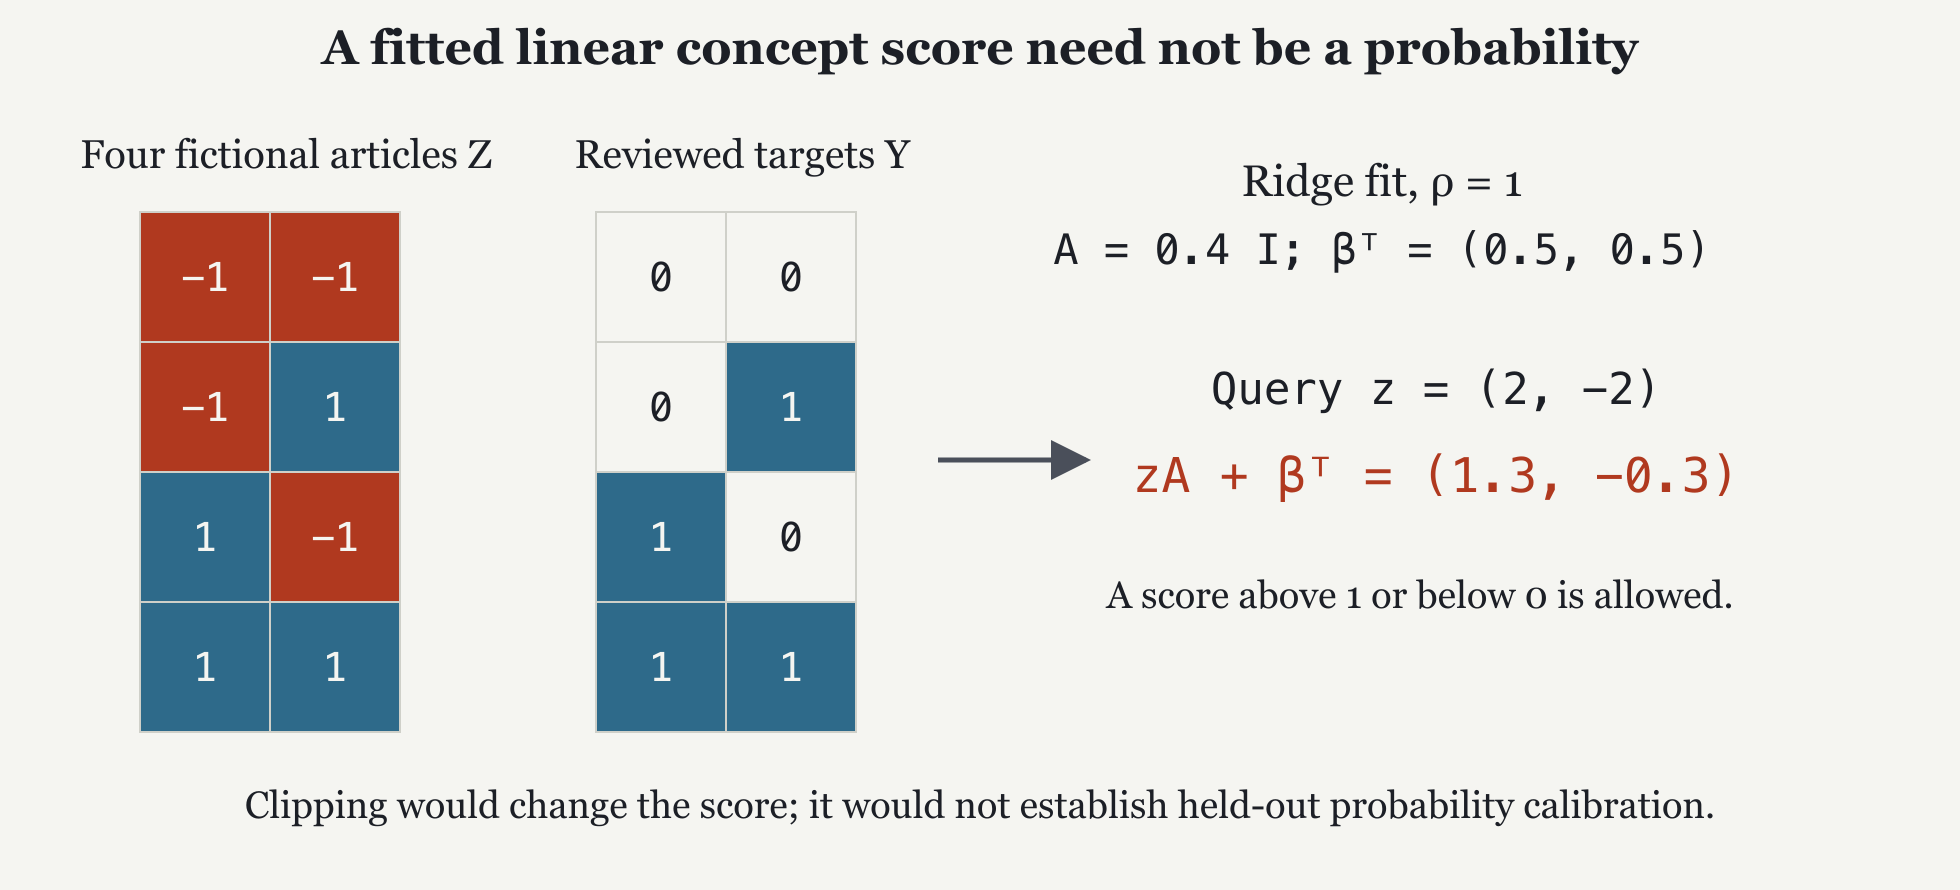

*An illustrative ridge fit: four invented article rows determine slopes and intercepts; an extrapolating row produces scores outside the probability interval. These are arithmetic examples, not Anthropology evaluation results.*

Each corpus would need its own fitted coefficients. Shared target identifiers make the outputs comparable in meaning; they do not make the input bases interchangeable. Concepts overlap, so $A$ need not be orthogonal or even square. This semantic transformation does not inherit the reconstruction guarantees of $W$.

### Laboratory: Fit both ridge targets from the four reviewed rows

`ridge_z` contains four fictional two-coordinate article rows; `ridge_y`
contains two fully observed binary target columns. `rho` is the ridge
penalty. Centering both tables leaves the intercept unpenalized. Solving
(ZᵀZ+ρI)A=ZᵀY gives the slope matrix `slopes`; `intercept` restores
target means. `query_row` is the extrapolating (2,−2) row. Missing labels
are illustrated separately with `None`; they are excluded, never zeroed.

In [24]:
ridge_z = np.array([[-1,-1],[-1,1],[1,-1],[1,1]],dtype=float)
ridge_y = np.array([[0,0],[0,1],[1,0],[1,1]],dtype=float)
rho = 1.
zc, yc = ridge_z-ridge_z.mean(axis=0), ridge_y-ridge_y.mean(axis=0)
slopes = np.linalg.solve(zc.T@zc+rho*np.eye(2),zc.T@yc)
intercept = ridge_y.mean(axis=0)-ridge_z.mean(axis=0)@slopes
training_scores = ridge_z@slopes+intercept
query_row = np.array([2.,-2.])
query_scores = query_row@slopes+intercept
assert_close(slopes,.4*np.eye(2))
assert_close(intercept,[.5,.5])
assert_close(training_scores,[[.1,.1],[.1,.9],[.9,.1],[.9,.9]])
assert_close(query_scores,[1.3,-.3])
partially_reviewed = [1,None,0,None]
assert [label for label in partially_reviewed if label is not None] == [1,0]
record_result("ridge_first_slope",slopes[0,0])
record_result("ridge_extrapolation_first",query_scores[0])
record_result("ridge_extrapolation_second",query_scores[1])
print("Slopes:\n",slopes,"\nIntercept:",intercept,"\nTraining scores:\n",training_scores,"\nExtrapolation:",query_scores)

ridge_first_slope = 0.4
ridge_extrapolation_first = 1.3
ridge_extrapolation_second = -0.3
Slopes:
 [[0.4 0. ]
 [0.  0.4]] 
Intercept: [0.5 0.5] 
Training scores:
 [[0.1 0.1]
 [0.1 0.9]
 [0.9 0.1]
 [0.9 0.9]] 
Extrapolation: [ 1.3 -0.3]


## A score becomes a probability only after another question

First define what is being predicted. One possible event is: “Under this annotation protocol, reviewers judge that this article substantially discusses databases.” It is not “this person is a database person.”

A logistic predictor maps a linear score through a smooth S-shaped function whose output lies between zero and one. Calibration means agreement between predicted probabilities and observed frequencies; the logistic bound alone does not establish it. The distinction is developed in [Guo and colleagues' study of calibration](https://proceedings.mlr.press/v70/guo17a.html).

A reliability diagram offers a simple check. In an invented test set, collect 100 articles assigned probabilities near 0.8. Suppose reviewers mark 55 as positive. Plot their mean prediction near 0.8 horizontally and the observed fraction 0.55 vertically. A well-calibrated bin would lie near the diagonal, where those numbers agree. This example is hypothetical; Anthropology has not reported such a calibration experiment.

Repeat across probability ranges, report the number of articles in each bin and uncertainty, and inspect relevant sources and periods separately. Small bins can fluctuate substantially. Prevalence is the fraction of articles with a positive target. A model that predicts this overall fraction for every article can be calibrated yet poor at ranking individual articles. Discrimination is its ability to distinguish positive from negative cases. Calibration and discrimination therefore need separate evaluation, with articles reserved for testing rather than reused for fitting or tuning.

**Checkpoint.** The toy linear model predicts 1.3. Can the interface print “130% confidence”? **Answer:** No. It can display a labeled score. A probability needs a defined target, a suitable model, and held-out evidence that its estimates behave like probabilities.

### Laboratory: Fit a logistic toy model, then test a reliability bin

A **new, synthetic extension** fits a binary logistic model to the first
ridge target, where positive means the fictional reviewer selected that
concept. `logistic_weights` are two slopes and `logistic_intercept` is the
baseline. Gradient descent minimizes mean binary log loss plus 0.1/2 times
the squared slope length; the intercept is not penalized. This is training
arithmetic, not held-out validation. Separately, `test_predictions` and
`test_labels` construct the book's hypothetical 100-article reliability
bin: prediction 0.8, 55 positives. `calibration_gap` is absolute mean
prediction minus observed frequency. A constant prevalence predictor
illustrates why calibration alone cannot discriminate individual cases.

In [25]:
logistic_weights = np.zeros(2)
logistic_intercept = 0.
logistic_penalty, learning_rate = .1, .2
for step in range(2000):
    fitted = sigmoid(ridge_z@logistic_weights+logistic_intercept)
    errors = fitted-ridge_y[:,0]
    gradient = ridge_z.T@errors/4+logistic_penalty*logistic_weights
    intercept_gradient = errors.mean()
    logistic_weights -= learning_rate*gradient
    logistic_intercept -= learning_rate*intercept_gradient
logistic_fitted = sigmoid(ridge_z@logistic_weights+logistic_intercept)
assert np.all((logistic_fitted>0)&(logistic_fitted<1))
assert np.linalg.norm(gradient)<1e-8
test_predictions = np.full(100,.8)
test_labels = np.array([1.]*55+[0.]*45)
observed_frequency = test_labels.mean()
calibration_gap = abs(test_predictions.mean()-observed_frequency)
prevalence_predictions = np.full(100,observed_frequency)
assert_close(calibration_gap,.25)
assert_close(prevalence_predictions.mean(),observed_frequency)
assert np.ptp(prevalence_predictions)==0
record_result("logistic_first_slope",logistic_weights[0])
record_result("logistic_positive_probability",logistic_fitted[-1])
record_result("hypothetical_calibration_gap",calibration_gap)
print("Logistic slopes:",logistic_weights,"; training outputs:",logistic_fitted)
print("Reliability bin: n=100; predicted=0.8; observed=",observed_frequency,"; gap=",calibration_gap)

logistic_first_slope = 1.63350617016
logistic_positive_probability = 0.836649382984
hypothetical_calibration_gap = 0.25
Logistic slopes: [1.633506 0.      ] ; training outputs: [0.163351 0.163351 0.836649 0.836649]
Reliability bin: n=100; predicted=0.8; observed= 0.55 ; gap= 0.24999999999999978


## Why an article model cannot simply label a person

A person profile $b$ has been background-adjusted and normalized. It describes the direction of distinctive coverage. An article row $z$ has undergone neither of those person-level operations. Their equal number of coordinates does not make them the same kind of observation.

For a person score row $u$, the earlier chapters reconstructed an approximate profile as $\overline b+uW^\top$. Use the people basis and article predictor from the same corpus and news-coordinate version. Let $s_{\mathrm{person}}$ denote the $1\times m$ score row obtained by applying the article predictor to this reconstructed profile. Substitution gives

$$
s_{\mathrm{person}}=\overline b A+\beta^\top+u(W^\top A).
$$

The product $W^\top A$ has shape $r\times m$: it describes how moving along each of the $r$ people directions would change those linear scores. This is a valid algebraic identity. Its interpretation as a useful prediction about a person remains an untested use outside the article model's training distribution. Neither restoring the mean nor adding the intercept solves that problem.

Another possible quantity is the fraction of a person's associated articles predicted to discuss a concept. That answers a coverage question, with uncertainty from both article attribution and classification. For a nonlinear predictor, predicting an average row and averaging individual predictions can differ. A future system must specify which quantity it means and evaluate it on independently reviewed person-level examples.

### Laboratory: Check the substitution and nonlinear averaging distinction

The earlier ridge model has two input coordinates, while the people
fixture has three. This cell therefore introduces a **separate arbitrary**
three-by-two `article_slopes` table and two intercepts `article_baseline`.
`restored_profile` adds the people mean to A's reconstructed centered row.
The two routes to the linear score are algebraically identical; neither
is a validated person probability. For scalar rows 0 and 2, applying a
sigmoid after averaging also differs from averaging the two sigmoids.

In [26]:
article_slopes = np.array([[.4,0],[0,.4],[.2,-.1]])
article_baseline = np.array([.5,.5])
restored_profile = people_mean+scores[0]@loading.T
direct_person_score = restored_profile@article_slopes+article_baseline
factored_person_score = people_mean@article_slopes+article_baseline+scores[0]@(loading.T@article_slopes)
assert_close(direct_person_score,factored_person_score)
nonlinear_inputs = np.array([0.,2.])
predict_average = sigmoid(nonlinear_inputs.mean())
average_predictions = sigmoid(nonlinear_inputs).mean()
assert abs(predict_average-average_predictions)>.01
record_result("person_score_identity_first",direct_person_score[0])
record_result("nonlinear_average_gap",predict_average-average_predictions)
print("Algebraic person scores:",direct_person_score,"; outside article training semantics.")
print("Predict average / average predictions:",predict_average,average_predictions)

person_score_identity_first = 0.844842609234
nonlinear_average_gap = 0.0406600396411
Algebraic person scores: [0.844843 0.331805] ; outside article training semantics.
Predict average / average predictions: 0.7310585786300049 0.6903985389889411


## Aligning maps needs anchors and room to test them

Suppose two corpora contain reviewed representations of the same people. An anchor is a pair of rows known to describe the same entity in the two corpora. An orthogonal Procrustes fit tries to rotate or reflect one set of such rows toward the other. For this alignment only, let $M$ count paired anchors and $k$ count coordinates in each representation. Let $X$ and $Y$ be their centered $M\times k$ tables, with matching entities in the same row; $Y$ here is an anchor table, not the preceding concept-target matrix. Let $Q_{\mathrm{align}}$ be a $k\times k$ alignment matrix, distinct from the SVD factor $Q$. The identity $I$ now has shape $k\times k$. The fit minimizes $\lVert XQ_{\mathrm{align}}-Y\rVert_F^2$ subject to the orthogonality constraint $Q_{\mathrm{align}}^\top Q_{\mathrm{align}}=I$.

The constraint preserves distances within the chosen coordinate geometry. It cannot correct every difference in populations, source coverage, or scaling. Shared names are not enough; the anchors must be correctly identified and substantively comparable.

The published models share 60 canonical people. Sixty centered rows in 60 dimensions have rank at most 59: subtracting their mean makes the rows sum to zero, creating a dependence. Consequently, they cannot determine a full 60-dimensional alignment from independent evidence in every direction. Reserving anchors for testing leaves still fewer for fitting. A lower-dimensional or regularized approach is possible, but its assumptions and performance need evaluation. See [Matching axes](https://firstpair.org/read/eigentimes-math/chapters/chapter-012.html#matching-axes) for the prerequisite distinction between comparing directions and assigning correspondences.

### Laboratory: Fit a tiny alignment and compute the rank shortage

`anchors_x` contains four invented centered two-dimensional anchors;
`anchors_y` is a known 90-degree transformation of the same rows.
The fit estimates the orthogonal `alignment` from paired training rows.
`heldout_x` is a separate illustrative row excluded from fitting; a
noiseless fixture proves the arithmetic, not real cross-corpus quality.
`centered_sixty` then centers 60 synthetic rows in 60 dimensions and
computes rank 59. The real 60 shared canonical people are a dated count;
this matrix only demonstrates the same rank bound.

In [27]:
anchors_x = np.array([[-1,-1],[-1,1],[1,-1],[1,1]],dtype=float)
known_alignment = np.array([[0.,-1.],[1.,0.]])
anchors_y = anchors_x@known_alignment
align_u,align_s,align_vt = np.linalg.svd(anchors_x.T@anchors_y)
alignment = align_u@align_vt
heldout_x = np.array([.3,-.7])
assert_close(alignment.T@alignment,np.eye(2))
assert_close(anchors_x@alignment,anchors_y)
assert_close(heldout_x@alignment,heldout_x@known_alignment)
centered_sixty = np.eye(60)-np.ones((60,60))/60
rank_sixty = np.linalg.matrix_rank(centered_sixty)
assert rank_sixty==59
record_result("sixty_centered_rank",rank_sixty)
record_result("alignment_heldout_error",np.linalg.norm(heldout_x@alignment-heldout_x@known_alignment))
print("Fitted alignment:\n",alignment,"\nRank of centered 60×60 rows:",rank_sixty)

sixty_centered_rank = 59
alignment_heldout_error = 0
Fitted alignment:
 [[ 0. -1.]
 [ 1.  0.]] 
Rank of centered 60×60 rows: 59


<a id="following-evidence"></a>

# Following the evidence all the way back

The mathematics makes research paths visible. Following them well means keeping track of what each step establishes. This chapter uses the paper's 2 October 2026 edition and its unchanged 1 October vector snapshot. The links are live entry points; the numbers below describe that dated audit.

## A Jeff Dean journey in four steps

1. Open [Jeff Dean's Anthropology profile](https://anthropolo.gy/people/jeff-dean#signals). This is the identity and source-record starting point. The profile's signal links include several news directions; no single one is “Jeff Dean's eigenvector.”

2. Open the explicit [Dean view on news axis N24 and people pattern P2](https://anthropolo.gy/vectors?model=eigenhacks%3Aeigen%3Ahn1%3Apeople%3Av1%3Abcaccd95b794&news=24&people=2&from=people&window=all&person=jeff-dean). The model selector matters: this is the Eigen Hacks `hn1` people model. Its all-history Dean profile uses **253 qualified candidate articles**. The displayed news coordinate is approximately **+0.433** and the people coordinate **+0.371**. N24's leading terms include `learn`, `machin`, `model`, and `deep`. The two scores measure different projections; they are not probabilities or two estimates of the same number.

3. Inspect neighbors. The audit records Sanjay Ghemawat at cosine **0.7514** with 31 candidate articles, Andrew Ng at **0.7413** with 394, and Noam Shazeer at **0.7403** with 38. These cosines use the retained 24-dimensional people space. The corresponding centered 60-dimensional comparisons are 0.7082, 0.6380, and 0.6687. Compression changes the numerical similarity. Follow the [Andrew Ng selection](https://anthropolo.gy/vectors?model=eigenhacks%3Aeigen%3Ahn1%3Apeople%3Av1%3Abcaccd95b794&news=24&people=2&from=people&window=all&person=andrew-ng), then [Ng's canonical profile](https://anthropolo.gy/people/andrew-ng#signals), to inspect another person's evidence.

4. Read an article. The Dean evidence includes a [WIRED interview published on 14 December 2019](https://www.wired.com/story/googles-ai-chief-do-more-less-data/). Its HN-derived record carries 15 December. Keep those dates distinct: the publisher and the archive record describe different observations. Then return to the map and ask which details in the source support the numerical association.

The related [Eigen Hacks people view](https://eigenhacks.com/people-vectors/#news-axis=24) and [Eigen Times people view](https://eigentimes.com/v2/people-vectors/) extend the exploration into their separate corpora. Their axis numbers are local addresses, not universal concepts.

The audited current-news overlay has zero newly qualified article-person joins. It can display recent articles in the fixed news basis, but proximity to Dean's historical profile does not establish that a recent article mentions him. This distinction is precisely where a promising research lead still needs evidence.

### Laboratory: Inspect the frozen evidence without pretending to refit it

**Dated evidence, not live or recomputed model output:** `dean_snapshot`
and `audited_neighbors` transcribe the manuscript's 2 October 2026
edition / 1 October vector snapshot. The archive and original embeddings
are not bundled, so this cell does not regenerate the real profile or
real cosine scores. It computes only differences and orderings of those
explicitly supplied values. All live exploration links and source dates
remain in the manuscript section directly above.
`other_audit_pairs` similarly preserves the three cross-person comparisons
from the neighbors chapter, without inventing missing vector rows.

In [28]:
dean_snapshot = dict(person="Jeff Dean",articles=253,news_N24=.433,people_P2=.371,
                     model="eigenhacks:eigen:hn1:people:v1:bcaccd95b794",edition="2026-10-02",
                     snapshot="2026-10-01",qualified_new_joins=0)
audited_neighbors = [("Sanjay Ghemawat",31,.7514,.7082),("Andrew Ng",394,.7413,.6380),
                     ("Noam Shazeer",38,.7403,.6687)]
other_audit_pairs = [("LeCun/Bengio",.9587,.9118),("Ellison/Siebel",.7198,.5800)]
for name,support,reduced,full in audited_neighbors:
    print(f"DATED {name}: support={support}; reduced={reduced:.4f}; full={full:.4f}; difference={reduced-full:+.4f}")
for name,reduced,full in other_audit_pairs:
    print(f"DATED {name}: reduced={reduced:.4f}; full={full:.4f}; difference={reduced-full:+.4f}")
print("DATED Zuckerberg/Gates: hn1=0.0782; general=-0.1137 (different corpus geometries)")
print("DATED Ellison/Siebel support: 416 / 11; not a confidence interval.")
assert dean_snapshot["qualified_new_joins"]==0
record_result("dated_Dean_Ng_cosine_difference",audited_neighbors[1][2]-audited_neighbors[1][3])
record_result("dated_Dean_article_support",dean_snapshot["articles"])
print("WIRED publisher date: 2019-12-14; HN-derived record: 2019-12-15.")

DATED Sanjay Ghemawat: support=31; reduced=0.7514; full=0.7082; difference=+0.0432
DATED Andrew Ng: support=394; reduced=0.7413; full=0.6380; difference=+0.1033
DATED Noam Shazeer: support=38; reduced=0.7403; full=0.6687; difference=+0.0716
DATED LeCun/Bengio: reduced=0.9587; full=0.9118; difference=+0.0469
DATED Ellison/Siebel: reduced=0.7198; full=0.5800; difference=+0.1398
DATED Zuckerberg/Gates: hn1=0.0782; general=-0.1137 (different corpus geometries)
DATED Ellison/Siebel support: 416 / 11; not a confidence interval.
dated_Dean_Ng_cosine_difference = 0.1033
dated_Dean_article_support = 253
WIRED publisher date: 2019-12-14; HN-derived record: 2019-12-15.


## “Today's database news against today's database CEOs”

This query combines three tables: articles relevant to databases on a chosen date, sourced executive roles valid on that date, and qualified links between articles and people. The word “today” must resolve to an explicit date in all three.

Let $t$ be the queried date, $t_{\mathrm{start}}$ a role's known start date, and $t_{\mathrm{end}}$ its known exclusive end date. Exclusive means the role is no longer valid on that endpoint. The symbol $\leq$ includes equality, whereas $<$ does not. Validity at the queried date can then be written $t_{\mathrm{start}}\leq t<t_{\mathrm{end}}$. This is a useful interval convention, not permission to invent an end date. An unknown end does not by itself prove that a role continues today; retain the source's as-of date and uncertainty.

The paper's dated role query reaches executive records that have no supported profile in either published people model. The correct result is a visible gap, not a fabricated point on the map. Larry Ellison's historical database coverage also cannot be substituted for a claim that he is the current CEO of a database company. A founder, a chair, and a current chief executive are distinct roles.

The research query can therefore show topic-ranked articles beside sourced roles while leaving missing joins visible. A completed current-CEO comparison would need additional profile coverage and article attribution. A larger identity catalog alone supplies neither.

### Laboratory: Execute a dated join while retaining unknowns

This entirely fictional table uses ISO dates, whose lexical order matches
date order. `role_at` returns `valid`, `invalid`, or `unknown`: a known
exclusive end date determines an interval, while an unknown end plus an
earlier as-of date cannot establish validity at a later query date.
A valid CEO with no supported profile remains visible with an explicit
gap. A topic-relevant article is not linked to that person without a
qualified attribution row. Founder and chair roles do not pass a CEO filter.

In [29]:
query_date = "2026-10-02"
roles = [dict(person="Fictional Ada",role="CEO",start="2025-01-01",end="2027-01-01",as_of="2026-10-02"),
         dict(person="Fictional Bea",role="CEO",start="2024-01-01",end="2026-10-02",as_of="2026-10-02"),
         dict(person="Fictional Cy",role="CEO",start="2023-01-01",end=None,as_of="2024-01-01"),
         dict(person="Fictional Dee",role="chair",start="2025-01-01",end="2027-01-01",as_of="2026-10-02")]
def role_at(role, date):
    if date < role["start"]:
        return "invalid"
    if role["end"] is None:
        return "valid" if date==role["as_of"] else "unknown"
    return "valid" if date < role["end"] else "invalid"
assert [role_at(row,query_date) for row in roles]==["valid","invalid","unknown","valid"]
current_ceos = [row for row in roles if row["role"]=="CEO" and role_at(row,query_date)=="valid"]
profiles = {}
qualified_links = set()
query_results = [(row["person"],profiles.get(row["person"]), ("today-topic-article",row["person"]) in qualified_links) for row in current_ceos]
assert query_results==[("Fictional Ada",None,False)]
record_result("synthetic_current_ceos",len(current_ceos))
print("person / supported profile / qualified article link:",query_results)

synthetic_current_ceos = 1
person / supported profile / qualified article link: [('Fictional Ada', None, False)]


## One name, several kinds of evidence

Canonical identity answers which entity a record refers to. A Wikipedia/Wikidata correspondence can help confirm the node; it does not validate every article placed in a same-name bucket. Reviewed Devreal mappings reuse the existing canonical node. Name similarity alone never settles that correspondence.

A typed graph assertion answers another question: what relationship does a particular source state? “Employed by,” “reports to,” “coauthored,” and “competes with” have different meanings and sometimes different directions. Two people working for the same organization need not have overlapped or known each other. A co-mention records shared appearance in an article, leaving the relationship unspecified.

Dates and review states travel with the assertion. A source assertion, a machine classification, and a curator's judgment are different kinds of support. A citation provides a route to inspection; it is not a measured probability of truth. Unknowns remain part of the record.

## A financing is an event, not a complete investment graph

Use a fictional announcement: “FinchDB raised $4 million; Harbor Ventures led and Cedar Capital participated.” There is one financing event, one recipient, and two explicitly named investor roles. The statement does not tell us how much either investor contributed. A partner quoted about the company is not automatically a personal investor or the deal's lead partner.

One mathematical picture is an *incidence table*: rows are entities and columns are events. An entry records participation, with a separate role label such as recipient, lead, or participant. This explanatory picture lets several entities meet at one event without inventing every possible pairwise relationship. The deployed catalog stores event records and optional investor relationships; it need not materialize this matrix.

Now imagine a separate fictional regulatory notice reports $1 million sold, later amended to $3 million. These are successive cumulative observations of an offering, so adding them to claim $4 million would double-count. An offering target, proceeds sold to date, and an announced round total answer different questions. First-sale, filing, and announcement dates also remain distinct until evidence reconciles the events.

The audited catalog contains **2,893 financing events** and **81 investor/partner relationship records**. The totals need not agree: an event can have several known investors or none. Eight historical investor associations are excluded from the financing total. Of the financings, 2,875 come from selected SEC issuer-reported notices; publication is not SEC verification, and the selected notices are not a census of venture rounds.

**Checkpoint.** A financing has no named investor. Is its event record necessarily incomplete collection? **Answer:** No. The source may establish the financing while withholding investor identities. Preserve the event and the unknown participants.

**Checkpoint.** Two profiles have cosine 0.95 and share an employer. May we add “colleagues”? **Answer:** Those facts motivate a search. They do not establish overlapping employment or a sourced colleague relationship.

### Laboratory: Preserve event roles and cumulative filing semantics

`financing` represents the fictional FinchDB announcement. Rows of
`event_incidence` are the recipient and two named investors; its one
column is the event. `role_labels` distinguishes recipient, lead, and
participant, and unknown investor amounts remain missing. `filing_sold`
holds two cumulative observations of a **separate** offering, so the
latest observation is 3 million, not their sum of 4 million. The final
catalog figures are explicitly the book's frozen audit, not new collection.

In [30]:
financing = dict(event="fictional-round-1",recipient="FinchDB",announced_total=4_000_000,
                 investors=[("Harbor Ventures","lead",None),("Cedar Capital","participant",None)])
event_entities = ["FinchDB","Harbor Ventures","Cedar Capital"]
event_incidence = np.ones((3,1),dtype=int)
role_labels = ["recipient","lead","participant"]
assert event_incidence.sum()==3 and len(financing["investors"])==2
assert all(amount is None for name,role,amount in financing["investors"])
filing_sold = [("fictional-initial",1_000_000),("fictional-amendment",3_000_000)]
latest_sold = filing_sold[-1][1]
assert latest_sold==3_000_000 and latest_sold!=sum(value for _,value in filing_sold)
dated_catalog = dict(financing_events=2893,investor_partner_records=81,excluded_historical_associations=8,selected_sec_notices=2875)
record_result("fictional_event_participants",event_incidence.sum())
record_result("latest_cumulative_sold",latest_sold)
record_result("dated_financing_events",dated_catalog["financing_events"])
print("Entity roles:",list(zip(event_entities,role_labels)),"\nIncidence:\n",event_incidence)
print("Unknown per-investor amounts retained; separate latest cumulative amount:",latest_sold)
print("DATED catalog, not a venture-round census:",dated_catalog)

fictional_event_participants = 3
latest_cumulative_sold = 3000000
dated_financing_events = 2893
Entity roles: [('FinchDB', 'recipient'), ('Harbor Ventures', 'lead'), ('Cedar Capital', 'participant')] 
Incidence:
 [[1]
 [1]
 [1]]
Unknown per-investor amounts retained; separate latest cumulative amount: 3000000
DATED catalog, not a venture-round census: {'financing_events': 2893, 'investor_partner_records': 81, 'excluded_historical_associations': 8, 'selected_sec_notices': 2875}


## Reading onward

Use [The Dual Geometry of People and News](https://firstpair.org/read/anthropology/) for the compact derivation, implementation audit, limitations, and source references behind this companion. Return to [The Mathematics of Eigen Times](https://firstpair.org/read/eigentimes-math/) for the foundations, especially text representation, covariance, SVD, named axes, and projection. Then explore [Anthropology](https://anthropolo.gy/) with three questions in view: which coordinates are being compared, what evidence supports the link, and which date does the claim describe?

<a id="notation"></a>

# Notation and shapes

All observation vectors in this companion are rows. A matrix direction, such as a column of $W$, is a column. The shapes below summarize the definitions introduced in the chapters. The letter $n$ counts fitted people; $N$ counts reviewed training articles for the proposed calibration fit.

| Symbol | Shape | Meaning |
|---|---|---|
| $x_a,\mu$ | $1\times d$ | Article embedding and its fitted reference mean |
| $V$ | $d\times K$ | Retained raw news directions |
| $R,D$ | $K\times K$ | Naming rotation and named-axis scale matrix |
| $c_a,y_a,z_a$ | $1\times K$ | Raw, named, and standardized article coordinates |
| $q_g,m_{pg}$ | $1\times K$ | Cell background and person-cell mean |
| $r_p,b_p$ | $1\times K$ | Balanced contrast and its unit direction |
| $B,H$ | $n\times K$ | Unit person rows and their centered rows |
| $\bar b$ | $1\times K$ | Mean unit person profile in the fitted population |
| $C_P$ | $K\times K$ | Equal-person covariance |
| $W$ | $K\times r$ | Retained people-pattern loadings |
| $u_p$ | $1\times r$ | A person's retained people coordinates |
| $WW^{\mathsf T}$ | $K\times K$ | Rank-$r$ projector in news-coordinate geometry |
| $Z,Y$ | $N\times K$, $N\times m$ | Article inputs and reviewed concept targets |
| $A,\beta$ | $K\times m$, $m\times1$ | Proposed concept slopes and intercepts |
| $W^{\mathsf T}A$ | $r\times m$ | Algebraic slopes from people directions to concept scores |

Here $d=384$, $K=60$, and $r=24$ in the published models described by the paper; the main fictional example uses $K=3$ and $r=2$. The bare $r$ is a retained dimension count; the indexed $r_p$ is a person's contrast row. The hypothetical number of ontology targets, $m$, is a modeling choice rather than a statement that every ontology concept has a trained classifier.

In the thin SVD $H=U\Sigma Q^{\mathsf T}$, $k_*=\min(n,K)$. The matrix $U$ is $n\times k_*$, $\Sigma$ is $k_*\times k_*$, and $Q$ is $K\times k_*$. Selecting the first $r$ columns of $Q$ with the fitted orientation produces $W$; the corresponding columns of $U$ and diagonal block of $\Sigma$ produce the score matrix $U_r\Sigma_r$. Coordinate sums $S_{pgw}$ and concept-score rows $s$ are different objects.

Time-window subscripts extend the same shapes: $b_{pw},q_{gw},m_{pgw}$ have $K$ coordinates, while $u_{pw}$ has $r$. The displacement $\Delta_p$, discarded squared length $Q_p$, attention share $\alpha_a$, and ranking score are scalars. In the alignment example, $X,Y$ are $M\times k$ anchor tables and $Q_{\mathrm{align}}$ is the $k\times k$ orthogonal map; that use of $Y$ is local to alignment.

<a id="answers"></a>

# Answers to the checks

**Check 1.** One unique background article and up to two person-article associations. The background describes a set of articles; the person profiles describe associations with each individual.

**Check 2.** The forward result is $1\times24$, the transpose is $24\times60$, and $WW^{\mathsf T}$ is $60\times60$. The returned row $hWW^{\mathsf T}$ is $1\times60$. The combined matrix has rank 24, so it cannot be the 60-dimensional identity.

**Check 3.** No. Diagonal entries describe individual variances. In the example the off-diagonal entries remain -0.6 after marginal standardization, so the two coordinates remain correlated.

**Check 4.** Repeating E1 inside the background would weight that reporting more heavily merely because it has two associated people. E1 should nevertheless enter both personal aggregations because each asks about the articles associated with a different person. Deduplicate within a set, not across two different research questions.

**Check 5.** P1 ranks N3 second: its loading 0.5949 is smaller in magnitude than N1's 0.7964. N3's own row ranks P1 ahead of P2 because 0.5949 exceeds 0.3087. The shared entry agrees exactly; the competing entries differ.

**Check 6.** $(0,1,0)$ also projects to $(1/\sqrt2,0)$ and returns as $(1/2,1/2,0)$. The two input rows differ only along a discarded direction, so the retained map cannot distinguish them.

**Check 7.** No. A and B move from cosine 0.0392 to 0.8211, a change of about 0.782. Total variance is an aggregate reconstruction quantity, not a bound on every pairwise angle.

**Check 8.** Yes. Its comparison background can change because other associated articles enter a cell, or older articles can leave a rolling window. A support threshold can also change which cells remain in the average. These mechanisms do not necessarily describe a change in the person's activities.

**Check 9.** No. A smaller topic coordinate can be outweighed by a larger attention share. Calling an article news about a person additionally needs a qualified article-person association and the underlying identity evidence. A ranking product cannot supply that link.

The three later checkpoints distinguish a linear score from a probability, a sourced financing event from its possibly unknown investors, and a coverage neighbor from a documented colleague. Their answers appear where each question is introduced so the required evidence remains next to the proposed inference.

### Laboratory: Turn Checks 1–9 and the checkpoints into assertions

Revisit each question before running this answer cell. `check_results`
collects nine Boolean tests corresponding to Checks 1–9. For Check 4,
`wrong_background` deliberately counts articles by their person links,
showing how double-counting E1 changes the denominator and the result.
For Check 8, `expired_mean` removes an old article from A's early cell;
this changes a personal mean without a newly associated article. The
three later checkpoints assert that a score of 1.3 is outside a probability
range, unknown investors may coexist with a sourced event, and similarity
plus a shared employer supplies no documented colleague edge by itself.

In [31]:
one_article_pairs = {("A","shared-article"),("B","shared-article")}
wrong_weights = counts[:4]*incidence[:,:4].sum(axis=0)
wrong_background = np.average(z[:4],axis=0,weights=wrong_weights)
expired_mean = (cell_counts[0,0]*cell_means[0,0]-z[0])/(cell_counts[0,0]-1)
check_results = [
    len({article for person,article in one_article_pairs})==1 and len(one_article_pairs)==2,
    (shape_row@shape_map).shape==(1,24) and (shape_row@shape_map@shape_map.T).shape==(1,60),
    np.allclose(np.diag(standard_cov),1) and abs(standard_cov[0,1])>.5,
    not np.allclose(wrong_background,backgrounds[0]),
    news_to_people(2)[0]==0 and people_to_news(0)[1]==2,
    np.allclose(second_axis@exact_loading@exact_loading.T,exact_return),
    abs(ab_reduced-ab_full)>1-retained_fraction,
    not np.allclose(updated_background,backgrounds[0]) and not np.allclose(expired_mean,cell_means[0,0]),
    np.argmax(strength)!=np.argmax(combined),
]
assert all(check_results)
assert query_scores[0]>1
event_with_unknown_investors = {"source":"fictional notice","investors":None}
assert event_with_unknown_investors["source"] and event_with_unknown_investors["investors"] is None
similarity, same_employer, documented_colleague_edge = .95,True,None
assert similarity>.9 and same_employer and documented_colleague_edge is None
record_result("numbered_checks_passed",sum(check_results))
print("Checks 1–9:",check_results,"; all three later checkpoints passed.")
print("Incorrect background from association duplication:",wrong_background)

numbered_checks_passed = 9
Checks 1–9: [True, True, np.True_, True, np.True_, True, np.True_, True, np.True_] ; all three later checkpoints passed.
Incorrect background from association duplication: [1.142857 0.428571 0.857143]


<a id="reproduction"></a>

# Reproducing the examples

The companion's public source bundle includes the Markdown manuscript, `scripts/examples.py`, `examples.json`, the figure sources and rendered images, Mermaid diagrams, packaging configuration, and a compact `paper-evidence.json` snapshot of reported real-data measurements. It also includes the supplied shelf artwork, which is kept separate from the reading editions. No restricted news archive or full catalog export is required to reproduce the fictional calculations.

From the Anthropology repository root, regenerate and check the numerical examples with:

```sh
python3 papers/mathematics-of-anthropology/scripts/examples.py
python3 papers/mathematics-of-anthropology/scripts/examples.py --check
```

NumPy supplies the numerical linear algebra. Figure generation retains editable SVGs and uses `rsvg-convert` for PNGs; Mermaid source files are included with their rendered diagrams. The README records the rendering and four-format build commands. The script verifies unit norms, covariance and eigenvector identities, the forward-return projection, residual orthogonality, cosine comparisons, and the ridge solution. These are arithmetic and implementation checks, not scientific validation of the real people model.

The reported Anthropology measurements retain their source dates and model identifiers. The Hacker News people model is `eigenhacks:eigen:hn1:people:v1:bcaccd95b794`; the general-news model is `eigentimes:eigen:v2:people:v1:47debba3db48`. The evidence snapshot records the source paper's checksum and audited implementation revisions. The public source inventory records the companion inputs and build revision. A refreshed news overlay must not silently replace the dated evidence used in this edition.

The mathematical pipeline can be checked from synthetic inputs, while the empirical claims require their stated source artifacts and attribution rules. Keeping those two kinds of reproducibility distinct is part of making the model useful for research.

### Laboratory: Collect cross-language results and finish the audit

`results` contains scalar outputs computed throughout this notebook.
The JSON marker below allows the Python and native OCaml executions to
be compared without comparing their display formatting. Numeric assertions
above also check matrices, support gates, losses, and lookup semantics.
Dated empirical fields are labeled `dated_`; they are supplied evidence,
not recomputed fits. All book prose, checks, notation, references, and
figure attachments remain in the notebook; rerunning requires no archive,
server, credentials, repository file, or network request.

In [32]:
assert len(results)>=45
print("RESULT_JSON " + json.dumps(results,sort_keys=True,allow_nan=False))
print(f"Finished {len(results)} comparable scalar results; all assertions passed.")

RESULT_JSON {"AB_full_cosine": 0.03920511395368208, "AB_reduced_cosine": 0.82110168971175, "A_balanced_N1": 0.8083333333333333, "A_discarded_energy": 0.2650295204610834, "A_people_P1": 0.5109278187065949, "A_profile_N1": 0.46876316083410763, "A_residual_norm": 1.7243960295322727, "A_volume_weighted_N1": 0.8375, "B_individual_retained": 0.46282595308329144, "D_people_P1": -1.1750434577136821, "N1_P1_loading": 0.7963582359182381, "X_attention_topic_score": 0.02, "Y_attention_topic_score": 0.05, "active_source_attention_mean": 0.05, "alignment_heldout_error": 0.0, "dated_Dean_Ng_cosine_difference": 0.10329999999999995, "dated_Dean_article_support": 253.0, "dated_N56_P19_loading": 0.4144960629, "dated_financing_events": 2893.0, "early_background_N1": 0.8, "eigenvalue_1": 0.49700682889788955, "eigenvalue_2": 0.28167334582924786, "eigenvalue_3": 0.18096540572886113, "exact_return_N1": 0.4999999999999999, "fictional_event_participants": 3.0, "first_singular_value": 1.4099742251514948, "hypoth